# Topic 1 — Introduction to Gaussian Mixture Models (GMM)

Let's start from the basic idea first. We'll go slowly, just like Spectral Clustering.

## What is GMM?

**Gaussian Mixture Model (GMM)** is a **probabilistic clustering algorithm**.

The main idea is:

> Instead of assuming that each cluster has a single center, GMM assumes that each cluster is generated by a **Gaussian (normal) distribution**.

So if we have 3 clusters, GMM assumes the data was generated from 3 Gaussian distributions:

$$
\text{Data}
\rightarrow
\text{Gaussian 1}
+
\text{Gaussian 2}
+
\text{Gaussian 3}
$$

Each Gaussian represents one cluster.

---

# K-Means vs GMM — Basic Difference

This is the first thing to understand.

### K-Means

K-Means thinks:

> "Every cluster has a center."

For example:

```text
       ● ●
     ● ● ●
       X

       X = centroid
```

It assigns a point to the closest centroid.

So:

$$
\text{Point}
\rightarrow
\text{Nearest Centroid}
\rightarrow
\text{Cluster}
$$

---

### GMM

GMM thinks:

> "Every cluster is a probability distribution."

For example:

```text
        Gaussian 1

          ●●
       ●●●●●
      ●●●●●●
       ●●●●

                  Gaussian 2

                    ●●
                  ●●●●●
                 ●●●●●●
```

Instead of simply saying:

```text
Point → Cluster 1
```

GMM can say:

```text
Point → 80% Cluster 1
        20% Cluster 2
```

This is called **soft clustering**.

---

# Why is this useful?

Imagine a point located between two clusters:

```text
Cluster 1             Cluster 2

 ● ● ●                  ● ● ●
 ● ● ●       ?          ● ● ●
 ● ● ●                  ● ● ●
```

K-Means must make a hard decision:

```text
? → Cluster 1
```

or:

```text
? → Cluster 2
```

GMM can express uncertainty:

$$
P(C_1\mid x)=0.6
$$

$$
P(C_2\mid x)=0.4
$$

So GMM is saying:

> "This point is more likely to belong to Cluster 1, but there is still a 40% possibility of Cluster 2."

---

# What does "Gaussian" mean?

A Gaussian is basically the familiar **bell-shaped probability distribution**.

For one dimension:

```text
             /\
           /    \
         /        \
       /            \
______/______________\______
```

The center is controlled by the **mean**.

The spread is controlled by the **variance**.

So a Gaussian is described mainly by:

$$
\text{Gaussian}
\rightarrow
\text{Mean}
+
\text{Variance}
$$

For multiple dimensions, we use:

$$
\text{Gaussian}
\rightarrow
\text{Mean Vector}
+
\text{Covariance Matrix}
$$

We'll study the covariance matrix in detail in the next topics.

---

# Why "Mixture"?

Suppose we have 2 clusters.

GMM assumes the data comes from a mixture of two Gaussian distributions:

$$
P(X)
=
\pi_1P(X\mid C_1)
+
\pi_2P(X\mid C_2)
$$

where:

* $\pi_1$ = weight of Gaussian 1
* $\pi_2$ = weight of Gaussian 2
* $P(X\mid C_1)$ = probability of the point under Gaussian 1
* $P(X\mid C_2)$ = probability of the point under Gaussian 2

The weights satisfy:

$$
\pi_1+\pi_2=1
$$

For example:

$$
\pi_1=0.7,\qquad\pi_2=0.3
$$

means the model estimates that roughly 70% of the data is associated with the first Gaussian and 30% with the second.

---

# The Core Idea

So remember this:

### K-Means

$$
\text{Cluster}
\rightarrow
\text{Centroid}
$$

### GMM

$$
\text{Cluster}
\rightarrow
\text{Gaussian Distribution}
$$

And therefore:

$$
\boxed{
\text{GMM}
\rightarrow
\text{Multiple Gaussian Distributions}
+
\text{Probabilistic Assignment}
}
$$


### 1. Mixture weight $\pi_1$

The weight tells us about the **Gaussian/cluster as a whole**, not about one particular point.

For example:

$$
\pi_1=0.7
$$

means:

> Gaussian 1 has a 70% mixture weight in the overall model.

You can roughly think of it as:

**"How much of the overall data distribution is represented by Gaussian 1?"**

It is the same for every point.

---

### 2. Gaussian probability $P(x\mid C_1)$

This is about a **specific point**.

It asks:

> **"How well does this particular point fit Gaussian 1?"**

Suppose point $x$ is close to Gaussian 1's center:

$$
P(x\mid C_1)=0.8
$$

and far from Gaussian 2:

$$
P(x\mid C_2)=0.1
$$

Then this point fits Gaussian 1 much better.

But **this is still not the final probability that the point belongs to Cluster 1**.

---

### 3. The actual "how much does this point belong to Cluster 1?" value

That's called the **responsibility**:

$$
P(C_1\mid x)
$$

This is what you were thinking of.

It combines:

* the Gaussian's overall weight $\pi_1$
* how well the point fits that Gaussian $P(x\mid C_1)$

Using Bayes' rule:

$$
P(C_1\mid x)
============

\frac{\pi_1P(x\mid C_1)}
{\sum_{j=1}^{K}\pi_jP(x\mid C_j)}
$$

So:

```text
π₁
↓
How important is Gaussian 1 overall?

P(x | C₁)
↓
How well does THIS point fit Gaussian 1?

P(C₁ | x)
↓
How much does THIS point belong to Cluster 1?
```

### Very important distinction

| Quantity       | Meaning                                                        |
| -------------- | -------------------------------------------------------------- |
| $\pi_1$        | Overall weight of Gaussian 1                                   |
| $P(x\mid C_1)$ | How well point $x$ fits Gaussian 1                             |
| $P(C_1\mid x)$ | Probability/responsibility that point $x$ belongs to Cluster 1 |

So **you were right that the final probability tells how much a point is associated with a cluster**, but **the mixture weight itself does not**. It describes the Gaussian's overall contribution to the mixture.


# Topic 2 — Gaussian Distribution

Now we'll understand **what the Gaussian distribution actually is**, because this is the foundation of GMM.

---

## 1. What is a Probability Distribution?

A probability distribution describes:

> **How likely different values of a variable are.**

For example, suppose we measure the height of many people.

We might observe:

```text
150  155  160  165  170  175  180  185  190
```

Some values occur more commonly than others.

A distribution describes this pattern.

---

# 2. Gaussian Distribution

A Gaussian distribution is the familiar **bell-shaped distribution**.

Its general shape is:

```text
                /\
              /    \
            /        \
          /            \
_________/________________\_________
```

The highest point is around the **mean**.

Values farther from the mean become less likely.

---

# 3. Mean Controls the Center

Suppose:

$$\mu=50$$

Then the Gaussian is centered around 50.

```text
                 /\
               /    \
             /        \
___________/____50______\___________
```

If we change the mean:

$$\mu=70$$

the entire distribution moves to the right.

```text
                         /\
                       /    \
                     /        \
___________________/____70______\____
```

So:

$$
\boxed{\mu\rightarrow\text{center/location of the Gaussian}}
$$

---

# 4. Variance Controls the Spread

Now keep:

$$\mu=50$$

but change the variance.

### Small variance

The points are concentrated close to the mean:

```text
                  /\
                /    \
              /        \
_____________/____50____\____________
```

### Large variance

The distribution spreads out:

```text
             ______
           /        \
         /            \
_______/______50________\________
```

So:

$$
\boxed{\sigma^2\rightarrow\text{spread of the Gaussian}}
$$

where $\sigma^2$ is the variance.

---

# 5. Probability Density

This is an important distinction.

A Gaussian gives us a **probability density**, not directly the probability of one exact continuous value.

The density tells us:

> **How concentrated is the distribution around this value?**

For a Gaussian centered at 50:

```text
                 /\
               /    \
             /        \
___________/____50______\___________
```

A point close to 50 has a **high density**.

A point far from 50 has a **low density**.

So:

$$
x\text{ close to }\mu
\rightarrow
\text{high density}
$$

$$
x\text{ far from }\mu
\rightarrow
\text{low density}
$$

---

# 6. Gaussian Formula

For a one-dimensional Gaussian:

$$
p(x)=\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$

There are two parameters:

$$
\mu=\text{mean}
$$

$$
\sigma^2=\text{variance}
$$

The formula essentially says:

> The farther $x$ is from $\mu$, the smaller its density becomes.

---

# 7. Simple Example

Suppose:

$$
\mu=50,\qquad\sigma^2=4
$$

Therefore:

$$
\sigma=2
$$

Consider two points:

$$
x_1=50
$$

and:

$$
x_2=56
$$

$x_1$ is exactly at the mean.

$x_2$ is 6 units away.

Therefore:

```text
x₁ = 50
↓
At center
↓
High density

x₂ = 56
↓
Far from center
↓
Low density
```

This is the basic mechanism GMM will use later.

---

# 8. Why Does GMM Need This?

Now connect this to clustering.

Suppose GMM has two Gaussian distributions:

```text
Gaussian 1              Gaussian 2

     /\                       /\
   /    \                   /    \
 /        \               /        \
```

For a particular point $x$, we calculate:

$$
P(x\mid C_1)
$$

and:

$$
P(x\mid C_2)
$$

These tell us how well the point fits each Gaussian.

Then, together with the mixture weights, we calculate:

$$
P(C_1\mid x)
$$

and:

$$
P(C_2\mid x)
$$

Those are the **cluster membership probabilities** we discussed earlier.

---

## The important chain

You can now see why the topics come in this order:

$$
\text{Gaussian}
\rightarrow
\text{Density of a point}
\rightarrow
P(x\mid C_k)
\rightarrow
\text{Cluster membership probability}
$$


# Topic 3 — Multivariate Gaussian

Now we move from a **1D Gaussian** to a Gaussian for data with **multiple features**.

Suppose each data point has two features:

$$
x=
\begin{bmatrix}
x_1\\
x_2
\end{bmatrix}
$$

For example:

```text
x₁ = height
x₂ = weight
```

Now a Gaussian needs more than just a single mean and variance.

It needs:

1. **Mean vector** → where the Gaussian is centered
2. **Covariance matrix** → how the Gaussian is spread and oriented

---

# 1. Mean Vector

Instead of one mean $\mu$, we have a mean for every feature.

$$
\mu=
\begin{bmatrix}
\mu_1\\
\mu_2
\end{bmatrix}
$$

For example:

$$
\mu=
\begin{bmatrix}
170\\
65
\end{bmatrix}
$$

This means the Gaussian is centered around:

```text
height ≈ 170
weight ≈ 65
```

So:

$$
\boxed{\text{Mean vector}\rightarrow\text{center of the Gaussian}}
$$

---

# 2. Why Do We Need Covariance?

Variance tells us how much **one feature spreads**.

But with multiple features, we also need to know:

> **How do the features vary together?**

For example, suppose:

```text
Height ↑
Weight ↑
```

If taller people tend to be heavier, height and weight have **positive covariance**.

If one increases while the other tends to decrease, they have **negative covariance**.

If they don't have a systematic **linear** relationship, covariance is close to zero.

So covariance tells us about the **joint variation** between features.

---

# 3. Covariance Matrix

For two features, the covariance matrix is:

$$
\Sigma=
\begin{bmatrix}
\operatorname{Var}(x_1)&\operatorname{Cov}(x_1,x_2)\\
\operatorname{Cov}(x_2,x_1)&\operatorname{Var}(x_2)
\end{bmatrix}
$$

Since:

$$
\operatorname{Cov}(x_1,x_2)
=
\operatorname{Cov}(x_2,x_1)
$$

the matrix is symmetric.

For example:

$$
\Sigma=
\begin{bmatrix}
4&3\\
3&9
\end{bmatrix}
$$

Here:

```text
4 → variance of feature 1

9 → variance of feature 2

3 → covariance between feature 1 and feature 2
```

Remember:

- **Diagonal elements** → variance of individual features
- **Off-diagonal elements** → covariance between features

---

# 4. What Does Covariance Change Visually?

This is the important part for GMM.

The covariance matrix determines how the Gaussian is **spread and oriented** around its mean.

### Covariance = 0

Suppose:

$$
\Sigma=
\begin{bmatrix}
4&0\\
0&4
\end{bmatrix}
$$

The two features have no linear covariance.

Because both variances are equal, the Gaussian looks roughly circular:

```text
        ●●●
      ●     ●
     ●       ●
      ●     ●
        ●●●
```

---

### Positive covariance

Suppose:

$$
\Sigma=
\begin{bmatrix}
4&3\\
3&9
\end{bmatrix}
$$

Now the two features tend to increase together.

The Gaussian becomes **tilted in a positive direction**:

```text
             ●●
          ●●
       ●●
    ●●
 ●●
```

The direction of the spread reflects the relationship between the features.

---

### Negative covariance

If:

$$
\Sigma=
\begin{bmatrix}
4&-3\\
-3&9
\end{bmatrix}
$$

the Gaussian tilts in the opposite direction:

```text
 ●●
    ●●
       ●●
          ●●
             ●●
```

So covariance does not simply make the Gaussian wider or narrower.

It helps determine the **orientation of the spread**.

---

# 5. The Three Things $\Sigma$ Controls

The covariance matrix controls the Gaussian's:

$$
\boxed{\text{Spread + Shape + Orientation}}
$$

while:

$$
\boxed{\mu\rightarrow\text{Location}}
$$

So together:

$$
\boxed{
\text{Gaussian}
\rightarrow
\text{Mean}+\text{Covariance}
}
$$

More specifically:

```text
Mean vector
    ↓
Where is the Gaussian located?

Covariance matrix
    ↓
How is the Gaussian spread?
How is it shaped?
How is it oriented?
```

---

# 6. Why This Matters for GMM

This is where GMM becomes more powerful than basic K-Means.

K-Means essentially creates clusters around **centroids** and assigns points according to their distance from those centroids.

GMM can model clusters with different shapes and orientations.

For example:

```text
       Cluster 1              Cluster 2

      /////////                 ●●●
    /////////                 ●●●●●
  /////////                   ●●●●●
```

Each Gaussian can have its own:

* mean
* covariance
* mixture weight

So for Gaussian $k$:

$$
\text{Gaussian}_k
\rightarrow
(\mu_k,\Sigma_k,\pi_k)
$$

where:

* $\mu_k$ = center/location
* $\Sigma_k$ = spread, shape, and orientation
* $\pi_k$ = mixture weight

This is the foundation we'll use when we get to the **actual GMM model**.

# Topic 4 — Covariance Types

Now we need to understand **how GMM is allowed to shape each Gaussian**.

This is controlled in Scikit-learn using:

```python
covariance_type
```

There are **4 types**:

```text
spherical
diag
tied
full
```

The difference is basically:

> **How much freedom does each Gaussian have to choose its spread and orientation?**

---

# 1. Spherical

Each Gaussian has **one variance value**.

For 2 features:

$$
\Sigma=
\begin{bmatrix}
\sigma^2&0\\
0&\sigma^2
\end{bmatrix}
$$

Both features have the same variance, and covariance is zero.

So the Gaussian is **circular** in 2D.

```text id="k9x0sh"
      ●●●
    ●     ●
   ●       ●
    ●     ●
      ●●●
```

### Meaning

```text
Same spread in every direction
        ↓
Circular Gaussian
```

It cannot tilt.

### Use when

You believe clusters are roughly **round/circular**.

---

# 2. Diagonal

Now each feature can have a **different variance**.

For two features:

$$
\Sigma=
\begin{bmatrix}
\sigma_1^2&0\\
0&\sigma_2^2
\end{bmatrix}
$$

The covariance is still zero.

So the Gaussian can be stretched:

```text id="v2j8xd"
       ●●●●●●
    ●●        ●●
  ●              ●
    ●●        ●●
       ●●●●●●
```

It can be wider in one direction than another, but it **cannot rotate/tilt**.

### Meaning

```text
Different spread
+
No correlation
↓
Axis-aligned ellipse
```

---

# 3. Full

This gives each Gaussian a complete covariance matrix.

For 2D:

$$
\Sigma=
\begin{bmatrix}
\sigma_1^2&\operatorname{Cov}(x_1,x_2)\\
\operatorname{Cov}(x_1,x_2)&\sigma_2^2
\end{bmatrix}
$$

Now covariance can be non-zero.

Therefore the Gaussian can:

* have different spreads
* have correlation
* rotate
* become tilted

Example:

$$
\Sigma=
\begin{bmatrix}
4&3\\
3&9
\end{bmatrix}
$$

This can produce a tilted ellipse.

```text id="q0k4xg"
             ●●
          ●●
       ●●
    ●●
 ●●
```

### Meaning

```text
Different spread
+
Correlation
+
Rotation
↓
Most flexible Gaussian
```

This is the **most flexible** covariance type.

---

# 4. Tied

This is different from the previous three.

With `tied`, **all Gaussian components share the same covariance matrix**.

Suppose there are two clusters:

$$
\Sigma_1=\Sigma_2=\Sigma
$$

For example:

$$
\Sigma=
\begin{bmatrix}
4&2\\
2&6
\end{bmatrix}
$$

Both clusters must use this same shape/orientation.

But they can still have different means:

$$
\mu_1\neq\mu_2
$$

So visually:

```text id="p2l1xj"
    ///////             ///////
  /////////           /////////
 /////////           /////////
```

Same shape and orientation, but different locations.

---

# The Difference in One Table

| Type        | Variance               | Covariance | Same covariance for all clusters? | Shape                  |
| ----------- | ---------------------- | ---------- | --------------------------------- | ---------------------- |
| `spherical` | Same in all directions | No         | No                                | Circle                 |
| `diag`      | Different per feature  | No         | No                                | Axis-aligned ellipse   |
| `full`      | Different              | Yes        | No                                | Rotated ellipse        |
| `tied`      | Different possible     | Yes        | **Yes**                           | Same shape/orientation |

---

# Easy Way to Remember

Think about **freedom**:

$$
\text{spherical}
\rightarrow
\text{diag}
\rightarrow
\text{full}
$$

More freedom as we move right.

```text
Spherical
   ↓
Circle

Diagonal
   ↓
Axis-aligned ellipse

Full
   ↓
Rotated ellipse

Tied
   ↓
All clusters share the same covariance
```

### Most important distinction

`full` vs `tied` is the one people often confuse:

**Full:**

Each cluster gets its **own** covariance.

$$
\Sigma_1\neq\Sigma_2
$$

**Tied:**

All clusters share **one** covariance.

$$
\Sigma_1=\Sigma_2=\cdots=\Sigma_k
$$

That's the core idea behind `covariance_type`.


# Each Cluster Has Its Own Feature Relationships and Covariance Structure


Yes — **if you are using `covariance_type="full"`**, that's correct.

For each Gaussian component (cluster), we calculate the covariance **between its features**.

For example, suppose each point has 2 features:

$$
x=
\begin{bmatrix}
x_1\\
x_2
\end{bmatrix}
$$

Cluster 1 can have:

$$
\Sigma_1=
\begin{bmatrix}
4&3\\
3&9
\end{bmatrix}
$$

and Cluster 2 can have:

$$
\Sigma_2=
\begin{bmatrix}
2&-1\\
-1&5
\end{bmatrix}
$$

So:

* Cluster 1: Feature 1 and Feature 2 have **positive covariance**.
* Cluster 2: Feature 1 and Feature 2 have **negative covariance**.
* Therefore, the two Gaussian clusters can have **different shapes and orientations**.

The important wording is:

> **Within each cluster, the covariance matrix describes how that cluster's features vary together.**

And with `full` covariance, **each cluster can have its own covariance matrix**.

For $K$ clusters:

$$
\Sigma_1,\Sigma_2,\ldots,\Sigma_K
$$

But with `tied` covariance, all clusters share the same covariance:

$$
\Sigma_1=\Sigma_2=\cdots=\Sigma_K
$$

So your understanding is correct **for full covariance**.


# How Covariance Determines Each Cluster’s Shape

Exactly — **we are NOT deciding the shape ourselves.** That's the important point.

When we say:

> "Cluster 1 has this covariance, so it has this shape"

we mean **GMM learns the covariance from the data**.

We are only choosing **how much freedom GMM is allowed to have** through `covariance_type`.

### Think of the process

Initially, we only have the data:

$$
X
$$

We don't know:

* which point belongs to which cluster
* where each cluster is centered
* what shape each cluster has
* how features vary together

GMM **learns all of these**.

For example:

$$
X
\rightarrow
\text{GMM}
\rightarrow
\mu_k,\Sigma_k,\pi_k
$$

The model learns:

* $\mu_k$ → where the Gaussian is located
* $\Sigma_k$ → its spread, shape, and orientation
* $\pi_k$ → its overall weight

### Then what do *we* choose?

We choose the **model assumption**.

For example:

```text id="1h0x8t"
covariance_type="spherical"
→ GMM is only allowed to learn circular shapes

covariance_type="diag"
→ GMM can learn stretched axis-aligned shapes

covariance_type="full"
→ GMM can learn stretched + tilted shapes
```

So we are **not saying**:

> "Cluster 1 should have this shape."

We're saying:

> **"GMM, you are allowed to learn this kind of shape from the data."**

Then GMM estimates the actual covariance from the data during the **EM algorithm**.

That's why `full` is more flexible: **the data determines each cluster's covariance rather than us manually specifying it.**


# Why Not Always Use Full Covariance?

You **can** use `full` covariance, and it is often a good default when you have enough data. But it is **not automatically the perfect representation**.

The reason is **model complexity**.

### 1. `full` gives the model the most freedom

For two features:

$$
\Sigma=
\begin{bmatrix}
\sigma_1^2&\operatorname{Cov}(x_1,x_2)\\
\operatorname{Cov}(x_1,x_2)&\sigma_2^2
\end{bmatrix}
$$

GMM can learn:

* different spread in each feature
* covariance between features
* tilted/rotated Gaussian shapes
* a **different covariance for every component**

That's very flexible.

---

### 2. But more freedom can cause overfitting

Imagine you have only **20 points** but ask GMM to learn several components, each with a full covariance matrix.

The model has many parameters to estimate.

It might start learning tiny details or random variations in your particular dataset rather than the true underlying structure.

This is called **overfitting**.

```text
Too simple
    ↓
Underfitting

Too flexible
    ↓
Overfitting

Good complexity
    ↓
Better generalization
```

---

### 3. Full covariance can also be computationally expensive

As the number of features increases, the covariance matrix becomes larger.

For $d$ features, a full covariance matrix has:

$$
d\times d
$$

entries.

Because the covariance matrix is symmetric, there are:

$$
\frac{d(d+1)}{2}
$$

unique covariance parameters **per Gaussian component**.

For example:

$$
d=2\rightarrow3
$$

unique parameters.

But:

$$
d=10\rightarrow55
$$

unique parameters **per component**.

And with 10 Gaussian components:

$$
10\times55=550
$$

covariance parameters alone.

So full covariance can become expensive and difficult to estimate reliably.

---

### 4. Sometimes the data doesn't need that freedom

Suppose your clusters actually look approximately circular.

Using `full` is unnecessary.

You could use:

```python
covariance_type="spherical"
```

You're making a simpler assumption:

> "I don't need GMM to learn complicated covariance relationships."

If the data really is circular, this simpler model can work very well.

---

### So the real idea

We don't choose:

> **"Which covariance type gives the most perfect representation?"**

We choose:

> **"Which covariance model provides enough flexibility without unnecessary complexity?"**

That's why GMM provides:

```text
spherical → simplest
diag      → more flexible
tied      → shared covariance
full      → most flexible
```

And in practice, you can **compare models**, often using criteria such as **BIC or AIC**, rather than assuming `full` is always best.

That's exactly why our plan includes **BIC/AIC and choosing the number of components** later.


# Topic 5 — GMM Model

Now we put everything together:

* **Mean** → where each Gaussian is located
* **Covariance** → shape, spread, orientation
* **Mixture weight** → how much that Gaussian contributes to the overall distribution

So each Gaussian component is described by:

$$
\text{Component}_k=
\left(\pi_k,\mu_k,\Sigma_k\right)
$$

---

## 1. Multiple Gaussians

Suppose we want **2 clusters**.

GMM assumes the data comes from two Gaussian components:

$$
\text{Data}
\rightarrow
\text{Gaussian}_1+\text{Gaussian}_2
$$

Each one has its own parameters.

For example:

$$
\mu_1=
\begin{bmatrix}
2\\
3
\end{bmatrix}
,\qquad
\mu_2=
\begin{bmatrix}
8\\
7
\end{bmatrix}
$$

These are the centers of the two Gaussian components.

Their covariance matrices could be:

$$
\Sigma_1=
\begin{bmatrix}
4&2\\
2&5
\end{bmatrix}
$$

$$
\Sigma_2=
\begin{bmatrix}
2&-1\\
-1&3
\end{bmatrix}
$$

So the two Gaussians can have **different shapes and orientations**.

---

# 2. Mixture Weight

Each Gaussian also has a weight.

For example:

$$
\pi_1=0.7
$$

$$
\pi_2=0.3
$$

and:

$$
\pi_1+\pi_2=1
$$

This means Gaussian 1 contributes **70%** to the overall mixture and Gaussian 2 contributes **30%**.

Again, this is an **overall property of the Gaussian component**, not the membership probability of an individual point.

---

# 3. Probability of a Point Under a Gaussian

Now take one particular point:

$$
x=
\begin{bmatrix}
3\\
4
\end{bmatrix}
$$

We can ask:

> How well does this point fit Gaussian 1?

That is:

$$
P(x\mid C_1)
$$

And:

> How well does it fit Gaussian 2?

That is:

$$
P(x\mid C_2)
$$

These values come from the Gaussian probability density determined by $\mu$ and $\Sigma$.

---

# 4. Overall Probability of the Point

Because the data comes from a **mixture** of Gaussians, the overall density of $x$ is:

$$
P(x)
=
\sum_{k=1}^{K}
\pi_kP(x\mid C_k)
$$

For two components:

$$
P(x)
=
\pi_1P(x\mid C_1)
+
\pi_2P(x\mid C_2)
$$

So we're combining the contribution from every Gaussian.

---

# 5. But We Want Cluster Membership

Ultimately, we want to know:

> **"Given this point, which Gaussian is it most associated with?"**

That's:

$$
P(C_k\mid x)
$$

Using Bayes' rule:

$$
P(C_k\mid x)
=
\frac{
\pi_kP(x\mid C_k)
}{
\sum_{j=1}^{K}
\pi_jP(x\mid C_j)
}
$$

This is the **responsibility** of Gaussian $k$ for point $x$.

---

# 6. Why This Is Called Soft Clustering

Suppose after calculating the probabilities we get:

$$
P(C_1\mid x)=0.8
$$

$$
P(C_2\mid x)=0.2
$$

Then GMM doesn't say:

> "The point definitely belongs to Cluster 1."

Instead:

> "The point has an 80% responsibility toward Cluster 1 and 20% toward Cluster 2."

Usually, for the final hard cluster label, we choose the component with the highest probability:

$$
\operatorname{cluster}(x)
=
\arg\max_k P(C_k\mid x)
$$

So the point would be assigned to Cluster 1.

---

# The Complete GMM Idea

Now everything we've learned connects:

$$
X
\rightarrow
\left(\pi_k,\mu_k,\Sigma_k\right)
\rightarrow
P(x\mid C_k)
\rightarrow
P(C_k\mid x)
\rightarrow
\text{Cluster}
$$

The important distinction is:

$$
\boxed{
\pi_k
=
\text{overall importance of Gaussian }k
}
$$

while:

$$
\boxed{
P(C_k\mid x)
=
\text{membership probability of point }x
}
$$

And **GMM's job is to learn** the $\pi_k$, $\mu_k$, and $\Sigma_k$ from the data.

That's where the **EM algorithm** comes in next.


Yes. This is an important notation distinction, so let's make it very clear.

## 1. What does capital $K$ mean?

**$K$ = total number of Gaussian components (clusters) in the GMM.**

Suppose we want 3 clusters:

$$
K=3
$$

Then we have:

$$
C_1,\quad C_2,\quad C_3
$$

and their parameters:

$$
(\pi_1,\mu_1,\Sigma_1),\quad
(\pi_2,\mu_2,\Sigma_2),\quad
(\pi_3,\mu_3,\Sigma_3)
$$

So **capital $K$ tells us how many components exist in total.**

---

## 2. What does small $k$ mean?

Small $k$ refers to **one particular component** among those $K$ components.

If:

$$
K=3
$$

then $k$ can be:

$$
k=1,\quad k=2,\quad k=3
$$

So when we write:

$$
P(C_k\mid x)
$$

we mean:

> "What is the probability that point $x$ belongs to component $k$?"

For example:

$$
k=1
$$

means we're asking about Cluster 1.

$$
k=2
$$

means we're asking about Cluster 2.

---

# 3. Look at the Formula

We had:

$$
P(C_k\mid x)
=
\frac{
\pi_kP(x\mid C_k)
}{
\displaystyle\sum_{j=1}^{K}\pi_jP(x\mid C_j)
}
$$

There are **two different indices** here: $k$ and $j$.

### $k$

The particular cluster we're currently asking about.

### $j$

A temporary index used to go through **all clusters** in the denominator.

And $K$ tells us where that loop stops.

Think of it like Python:

```python
for k in range(K):
    # calculate probability for component k
```

For the denominator:

```python
total = 0

for j in range(K):
    total += pi[j] * P_x_given_Cj
```

---

# 4. Small Numerical Example

Let's make a very small GMM with:

$$
K=2
$$

So there are two Gaussian components:

```text
Component 1 → Cluster 1
Component 2 → Cluster 2
```

Suppose for a particular point $x$ we know:

$$
\pi_1=0.6
$$

$$
\pi_2=0.4
$$

And suppose the Gaussian densities for this point are:

$$
P(x\mid C_1)=0.5
$$

$$
P(x\mid C_2)=0.2
$$

---

## Step 1 — Calculate contribution of Cluster 1

Take:

$$
\pi_1P(x\mid C_1)
$$

Substitute:

$$
=0.6\times0.5
$$

$$
=0.30
$$

So Cluster 1 contributes **0.30** for this point.

---

## Step 2 — Calculate contribution of Cluster 2

$$
\pi_2P(x\mid C_2)
$$

$$
=0.4\times0.2
$$

$$
=0.08
$$

So Cluster 2 contributes **0.08**.

---

## Step 3 — Calculate the denominator

The denominator considers **all $K=2$ components**:

$$
\sum_{j=1}^{K}\pi_jP(x\mid C_j)
$$

Therefore:

$$
=0.30+0.08
$$

$$
=0.38
$$

---

## Step 4 — Probability of belonging to Cluster 1

Now set:

$$
k=1
$$

Then:

$$
P(C_1\mid x)
=
\frac{0.30}{0.38}
$$

$$
P(C_1\mid x)\approx0.789
$$

So:

$$
\boxed{P(C_1\mid x)\approx78.9\%}
$$

---

## Step 5 — Probability of belonging to Cluster 2

Now set:

$$
k=2
$$

$$
P(C_2\mid x)
=
\frac{0.08}{0.38}
$$

$$
P(C_2\mid x)\approx0.211
$$

So:

$$
\boxed{P(C_2\mid x)\approx21.1\%}
$$

And notice:

$$
0.789+0.211=1
$$

Therefore the model says:

```text
Point x

Cluster 1 → 78.9%
Cluster 2 → 21.1%
```

So we would normally assign this point to **Cluster 1**, because it has the larger responsibility.

---

# 5. Now Understand $k$ vs $K$

This is the key:

$$
K=2
$$

means:

> **There are 2 clusters in total.**

But:

$$
k=1
$$

means:

> **Right now I'm calculating the probability for Cluster 1.**

And:

$$
k=2
$$

means:

> **Right now I'm calculating the probability for Cluster 2.**

So:

$$
\boxed{K=\text{total number of components}}
$$

$$
\boxed{k=\text{one particular component}}
$$

And the summation index $j$ simply goes through **all components**:

$$
j=1,2,\ldots,K
$$

That's why you see both lowercase $k$ and uppercase $K$ in the GMM equations.


# Topic 6 — Hard vs Soft Clustering

Before we go into the **EM algorithm**, let's make this distinction completely clear.

## 1. K-Means → Hard Clustering

K-Means gives each point **one cluster label**.

Suppose:

```text
Point A → Cluster 1
Point B → Cluster 1
Point C → Cluster 2
```

Mathematically, a point has a membership like:

$$
P(C_1\mid x)=1
$$

and:

$$
P(C_2\mid x)=0
$$

So the point is treated as **fully belonging to one cluster**.

---

# 2. GMM → Soft Clustering

GMM doesn't immediately force a point into one cluster.

Instead, it calculates a probability for **every Gaussian component**.

Suppose we have:

$$
K=2
$$

For a point $x$:

$$
P(C_1\mid x)=0.8
$$

$$
P(C_2\mid x)=0.2
$$

This means:

```text
Point x

Cluster 1 → 80%
Cluster 2 → 20%
```

So GMM says:

> "This point is more likely to belong to Cluster 1, but it also has some association with Cluster 2."

This is called **soft assignment**.

---

# 3. Where Does This Probability Come From?

Remember the formula:

$$
P(C_k\mid x)
=
\frac{
\pi_kP(x\mid C_k)
}{
\displaystyle\sum_{j=1}^{K}\pi_jP(x\mid C_j)
}
$$

This is called the **responsibility** of component $k$ for point $x$.

It combines two things:

### Mixture weight

$$
\pi_k
$$

> How important is Gaussian $k$ in the overall model?

### Gaussian density

$$
P(x\mid C_k)
$$

> How well does this particular point fit Gaussian $k$?

Together they determine:

$$
P(C_k\mid x)
$$

> How much should Gaussian $k$ be responsible for this point?

---

# 4. Small Example

Suppose:

$$
K=2
$$

and for point $x$:

$$
\pi_1=0.6,\qquad\pi_2=0.4
$$

Suppose the Gaussian densities are:

$$
P(x\mid C_1)=0.5
$$

$$
P(x\mid C_2)=0.2
$$

### Cluster 1

$$
\pi_1P(x\mid C_1)
=
0.6\times0.5
=
0.30
$$

### Cluster 2

$$
\pi_2P(x\mid C_2)
=
0.4\times0.2
=
0.08
$$

Total:

$$
0.30+0.08=0.38
$$

Therefore:

$$
P(C_1\mid x)
=
\frac{0.30}{0.38}
\approx0.789
$$

and:

$$
P(C_2\mid x)
=
\frac{0.08}{0.38}
\approx0.211
$$

So:

$$
\boxed{
x\rightarrow
\begin{cases}
78.9\%\text{ Cluster 1}\\
21.1\%\text{ Cluster 2}
\end{cases}
}
$$

---

# 5. Why Is This Better Sometimes?

Imagine two clusters overlap:

```text
Cluster 1              Cluster 2

 ● ● ●                 ● ● ●
 ● ● ●    ●            ● ● ●
 ● ● ●                 ● ● ●
```

The middle point is ambiguous.

K-Means has to say:

```text
Point → Cluster 1
```

GMM can say:

```text
Point → 55% Cluster 1
         45% Cluster 2
```

That probability gives us **uncertainty information**, which K-Means doesn't provide.

---

# 6. One Important Thing

GMM is still capable of producing normal cluster labels.

For example, if:

$$
P(C_1\mid x)=0.789
$$

and:

$$
P(C_2\mid x)=0.211
$$

we can simply choose the largest probability:

$$
\operatorname{cluster}(x)
=
\arg\max_k P(C_k\mid x)
$$

giving:

```text
x → Cluster 1
```

So GMM gives us **both**:

```text
Soft result:
[0.789, 0.211]

Hard result:
Cluster 1
```

---

## The key difference

$$
\boxed{
\text{K-Means}\rightarrow\text{Hard assignment}
}
$$

$$
\boxed{
\text{GMM}\rightarrow\text{Soft probabilistic assignment}
}
$$

And the probabilities that GMM calculates are called **responsibilities**.

The next major topic is **Expectation-Maximization (EM)** — this explains **how GMM actually learns $\mu$, $\Sigma$, and $\pi$ from the data**.


# Complete GMM Example

Suppose our data is:

$$
X=
\begin{bmatrix}
1\\
2\\
8\\
9
\end{bmatrix}
$$

We want:

$$
K=2
$$

So we assume there are **2 Gaussian components / 2 clusters**.

Our goal is eventually:

$$
x\rightarrow
P(C_1\mid x),P(C_2\mid x)
\rightarrow
\text{cluster}
$$

---

# Step 1 — Start with Initial Gaussian Parameters

GMM doesn't initially know the correct parameters.

For this small example, suppose we initialize:

### Gaussian 1

$$
\mu_1=2
$$

$$
\sigma_1^2=1
$$

$$
\pi_1=0.5
$$

### Gaussian 2

$$
\mu_2=8
$$

$$
\sigma_2^2=1
$$

$$
\pi_2=0.5
$$

So initially:

```text
Gaussian 1 → center = 2, variance = 1, weight = 0.5

Gaussian 2 → center = 8, variance = 1, weight = 0.5
```

These are **initial guesses**.

In a real GMM, these parameters are estimated/initialized by the algorithm and then refined through EM.

---

# Step 2 — Take One Point

Let's take:

$$
x=1
$$

We want to know:

> How much does Gaussian 1 explain this point?

and:

> How much does Gaussian 2 explain this point?

So we calculate:

$$
P(x\mid C_1)
$$

and:

$$
P(x\mid C_2)
$$

---

# Step 3 — Calculate Gaussian 1 Density

The 1D Gaussian density is:

$$
P(x\mid C_1)
=
\frac{1}{\sqrt{2\pi\sigma_1^2}}
\exp
\left(
-\frac{(x-\mu_1)^2}{2\sigma_1^2}
\right)
$$

Our values are:

$$
x=1,\qquad
\mu_1=2,\qquad
\sigma_1^2=1
$$

Substitute:

$$
P(1\mid C_1)
=
\frac{1}{\sqrt{2\pi}}
\exp
\left(
-\frac{(1-2)^2}{2}
\right)
$$

Calculate the difference:

$$
1-2=-1
$$

Square it:

$$
(-1)^2=1
$$

Therefore:

$$
P(1\mid C_1)
=
\frac{1}{\sqrt{2\pi}}
\exp\left(-\frac12\right)
$$

Approximately:

$$
\boxed{P(1\mid C_1)\approx0.242}
$$

---

# Step 4 — Calculate Gaussian 2 Density

Gaussian 2 has:

$$
\mu_2=8
$$

$$
\sigma_2^2=1
$$

Therefore:

$$
P(1\mid C_2)
=
\frac{1}{\sqrt{2\pi}}
\exp
\left(
-\frac{(1-8)^2}{2}
\right)
$$

Calculate:

$$
1-8=-7
$$

$$
(-7)^2=49
$$

Therefore:

$$
P(1\mid C_2)
=
\frac{1}{\sqrt{2\pi}}
\exp\left(-\frac{49}{2}\right)
$$

This is extremely small:

$$
\boxed{P(1\mid C_2)\approx0}
$$

So point $1$ fits Gaussian 1 much better.

---

# Step 5 — Include Mixture Weights

Remember:

$$
\pi_1=0.5
$$

and:

$$
\pi_2=0.5
$$

Calculate the contribution of each Gaussian.

### Gaussian 1

$$
\pi_1P(x\mid C_1)
=
0.5\times0.242
$$

$$
=0.121
$$

### Gaussian 2

$$
\pi_2P(x\mid C_2)
\approx
0.5\times0
$$

$$
\approx0
$$

---

# Step 6 — Calculate Responsibility

Now we calculate:

$$
P(C_k\mid x)
=
\frac{\pi_kP(x\mid C_k)}
{\displaystyle\sum_{j=1}^{K}\pi_jP(x\mid C_j)}
$$

For Cluster 1:

$$
P(C_1\mid x)
=
\frac{0.121}{0.121+0}
$$

Therefore:

$$
\boxed{P(C_1\mid x)\approx1}
$$

For Cluster 2:

$$
P(C_2\mid x)
=
\frac{0}{0.121+0}
$$

Therefore:

$$
\boxed{P(C_2\mid x)\approx0}
$$

So:

```text
Point x = 1

Cluster 1 → ~100%
Cluster 2 → ~0%
```

---

# Step 7 — Repeat for All Points

Now we repeat exactly the same process for:

$$
x=2,\quad x=8,\quad x=9
$$

Because our Gaussians are centered around 2 and 8, we'll get approximately:

| Point | $P(C_1\mid x)$ | $P(C_2\mid x)$ | Assignment |
| ----: | -------------: | -------------: | ---------- |
|     1 |         ≈ 1.00 |         ≈ 0.00 | Cluster 1  |
|     2 |         ≈ 1.00 |         ≈ 0.00 | Cluster 1  |
|     8 |         ≈ 0.00 |         ≈ 1.00 | Cluster 2  |
|     9 |         ≈ 0.00 |         ≈ 1.00 | Cluster 2  |

So the soft assignments are approximately:

$$
R=
\begin{bmatrix}
1&0\\
1&0\\
0&1\\
0&1
\end{bmatrix}
$$

Here each **row is one data point**, and each **column is one Gaussian component**.

For example, the first row:

$$
\begin{bmatrix}
1&0
\end{bmatrix}
$$

means:

> Point 1 has approximately 100% responsibility for Gaussian 1 and 0% for Gaussian 2.

---

# Step 8 — What Happens Next?

This is where the **EM algorithm** becomes important.

So far, we used our initial guesses:

$$
\mu_1=2,\quad\mu_2=8
$$

$$
\sigma_1^2=1,\quad\sigma_2^2=1
$$

$$
\pi_1=0.5,\quad\pi_2=0.5
$$

and used them to calculate the responsibilities.

This is called the:

# E-Step

We asked:

> **Given the current Gaussian parameters, how responsible is each Gaussian for each point?**

Then comes:

# M-Step

We use those responsibilities to **recalculate better values of**:

$$
\mu_k,\quad\Sigma_k,\quad\pi_k
$$

Then we repeat:

$$
\text{Initial parameters}
\rightarrow
\text{E-Step}
\rightarrow
\text{Responsibilities}
\rightarrow
\text{M-Step}
\rightarrow
\text{Updated parameters}
\rightarrow
\text{E-Step}
\rightarrow
\cdots
$$

until the parameters stop changing significantly.

---

## The entire GMM workflow

Now you can see the complete picture:

$$
X
\rightarrow
\text{Initialize }\mu,\Sigma,\pi
\rightarrow
\text{Calculate Gaussian densities}
\rightarrow
\text{Calculate responsibilities}
\rightarrow
\text{Update }\mu,\Sigma,\pi
\rightarrow
\text{Repeat}
\rightarrow
\text{Final probabilities}
\rightarrow
\text{Clusters}
$$

The example above showed you the **E-Step** numerically.

# Topic 7 — Expectation-Maximization (EM)

Now we get to the **core algorithm behind GMM**.

The main problem is:

> We don't know which points belong to which Gaussian, so how can we calculate the mean, covariance, and weight of each Gaussian?

GMM solves this using **Expectation-Maximization (EM)**.

---

## 1. What does EM do?

EM repeatedly performs two steps:

$$
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\cdots
$$

### E-Step — Expectation

Using the **current Gaussian parameters**, calculate:

> How much is each Gaussian responsible for each point?

This gives us the **responsibilities**:

$$
P(C_k\mid x_i)
$$

---

### M-Step — Maximization

Using those responsibilities, calculate **better Gaussian parameters**:

$$
\mu_k,\quad\Sigma_k,\quad\pi_k
$$

So:

```text id="3j6y3c"
Current parameters
       ↓
     E-Step
       ↓
Responsibilities
       ↓
     M-Step
       ↓
Updated parameters
       ↓
     Repeat
```

---

# 2. Why do we need to repeat?

Suppose initially we guess:

$$
\mu_1=2
$$

$$
\mu_2=8
$$

Those may not be perfect.

Using them, we calculate which points are more associated with each Gaussian.

Then we use those associations to calculate **better means**.

For example:

```text id="u3nq5m"
Initial means
     ↓
Calculate responsibilities
     ↓
Find better means
     ↓
Calculate new responsibilities
     ↓
Find even better means
     ↓
...
```

Eventually the parameters stop changing significantly.

That's **convergence**.

---

# 3. E-Step

The E-Step calculates:

$$
r_{ik}=P(C_k\mid x_i)
$$

Here:

* $i$ = which data point
* $k$ = which Gaussian component
* $r_{ik}$ = responsibility of component $k$ for point $i$

The formula is:

$$
r_{ik}
=
\frac{
\pi_kP(x_i\mid C_k)
}{
\displaystyle\sum_{j=1}^{K}
\pi_jP(x_i\mid C_j)
}
$$

So for **every point**, we calculate a probability for **every Gaussian**.

For example, with 4 points and 2 Gaussians:

$$
R=
\begin{bmatrix}
0.99&0.01\\
0.98&0.02\\
0.03&0.97\\
0.01&0.99
\end{bmatrix}
$$

Each row represents a point.

Each column represents a Gaussian.

For example, the first row:

$$
\begin{bmatrix}
0.99&0.01
\end{bmatrix}
$$

means:

> Point 1 has 99% responsibility for Gaussian 1 and 1% for Gaussian 2.

---

# 4. M-Step

Now we have responsibilities.

We use them to update the Gaussian parameters.

For each component $k$, we calculate three things:

### New mixture weight

$$
\pi_k^{new}
=
\frac{1}{N}
\sum_{i=1}^{N}r_{ik}
$$

### New mean

$$
\mu_k^{new}
=
\frac{
\displaystyle\sum_{i=1}^{N}r_{ik}x_i
}{
\displaystyle\sum_{i=1}^{N}r_{ik}
}
$$

### New covariance

For the multivariate case:

$$
\Sigma_k^{new}
=
\frac{
\displaystyle\sum_{i=1}^{N}
r_{ik}
(x_i-\mu_k^{new})
(x_i-\mu_k^{new})^T
}{
\displaystyle\sum_{i=1}^{N}r_{ik}
}
$$

Don't worry about memorizing the covariance equation yet. We'll calculate it slowly when we do the numerical dry run.

---

# 5. What Is Actually Happening?

Think about one Gaussian.

Suppose the responsibilities for Gaussian 1 are:

$$
\begin{bmatrix}
0.9\\
0.8\\
0.1\\
0.0
\end{bmatrix}
$$

This means:

```text id="bqxx0g"
Point 1 → strongly associated
Point 2 → strongly associated
Point 3 → weakly associated
Point 4 → not associated
```

When calculating the new mean of Gaussian 1, points 1 and 2 therefore have **more influence** on the mean.

So instead of saying:

> "Point belongs or doesn't belong."

GMM says:

> "Give each point an appropriate amount of influence."

That's the reason the responsibility values are used as **weights** in the M-Step.

---

# 6. The Complete EM Cycle

Now connect everything:

$$
\text{Initial }\mu,\Sigma,\pi
\rightarrow
\text{E-Step}
\rightarrow
\text{Responsibilities}
\rightarrow
\text{M-Step}
\rightarrow
\text{New }\mu,\Sigma,\pi
$$

Then repeat:

$$
\text{New parameters}
\rightarrow
\text{E-Step}
\rightarrow
\text{New responsibilities}
\rightarrow
\text{M-Step}
\rightarrow
\text{New parameters}
\rightarrow
\cdots
$$

Eventually:

$$
\boxed{\text{Parameters converge}}
$$

---

## The most important idea

**E-Step:**

> "Given my current Gaussians, which Gaussian is responsible for each point?"

**M-Step:**

> "Given these responsibilities, what should my Gaussians look like?"

So remember:

$$
\boxed{
\text{E-Step}
=
\text{Estimate responsibilities}
}
$$

$$
\boxed{
\text{M-Step}
=
\text{Update Gaussian parameters}
}
$$


# How do we decide which Gaussian parameters are better?

In GMM, the parameters are considered **better when they make the observed data more likely under the model**.

### Think about our example

We had:

$$
X=
\begin{bmatrix}
1\\
2\\
8\\
9
\end{bmatrix}
$$

Initially we guessed:

$$
\mu_1=2,\qquad \mu_2=8
$$

After the M-Step we got:

$$
\mu_1=1.5,\qquad \mu_2=8.5
$$

We should **not** say:

> 1.5 is better because it is lower than 2.

That's wrong.

Instead:

> **1.5 is better for Gaussian 1 because, given the responsibilities, it better represents the points associated with Gaussian 1.**

The same applies to variance and mixture weight.

---

## So how does GMM decide "better"?

The overall goal of GMM is to maximize the **likelihood of the observed data**.

In simple terms:

> **Choose Gaussian parameters that make the observed points as probable as possible.**

The process is:

$$
\text{Current parameters}
\rightarrow
\text{Calculate responsibilities}
\rightarrow
\text{Update parameters}
\rightarrow
\text{Higher likelihood}
$$

The M-Step mathematically chooses the parameter values that maximize the relevant likelihood/objective given the current responsibilities.

---

### Example intuition

Suppose these points belong strongly to Gaussian 1:

$$
1,\quad2
$$

If we choose:

$$
\mu_1=8
$$

that's obviously a poor representation because the points are far from 8.

If we choose:

$$
\mu_1=1.5
$$

the points are centered around the mean.

So the Gaussian gives them a much higher density.

Therefore, **1.5 is a better parameter for this data**.

---

## And this is why EM repeats

After the M-Step, we don't simply assume we're finished.

We use the new parameters to calculate new responsibilities:

$$
\text{New }\mu,\Sigma,\pi
\rightarrow
\text{New responsibilities}
$$

Then update again:

$$
\text{New responsibilities}
\rightarrow
\text{New }\mu,\Sigma,\pi
$$

This continues until the **likelihood stops improving significantly** (or another convergence criterion is reached).

### So remember:

> **GMM isn't trying to make $\mu$, $\Sigma$, or $\pi$ small. It is trying to find parameter values that best explain the observed data.**

And **"better" = better fit to the data according to the GMM likelihood objective.**


# Topic 7.3 — M-Step: Why the Update Formulas Work

Before moving to BIC/AIC, there's one important part of EM we should finish: **understanding what the M-Step is actually doing**.

We already saw that the M-Step calculates:

$$
\pi_k^{new}
=
\frac{1}{N}
\sum_{i=1}^{N}r_{ik}
$$

$$
\mu_k^{new}
=
\frac{
\displaystyle\sum_{i=1}^{N}r_{ik}x_i
}{
\displaystyle\sum_{i=1}^{N}r_{ik}
}
$$

and:

$$
\Sigma_k^{new}
=
\frac{
\displaystyle\sum_{i=1}^{N}
r_{ik}
(x_i-\mu_k^{new})
(x_i-\mu_k^{new})^T
}{
\displaystyle\sum_{i=1}^{N}r_{ik}
}
$$

Let's understand them intuitively.

---

## 1. Responsibility acts like importance

Suppose we have:

$$
X=
\begin{bmatrix}
1\\
2\\
8\\
9
\end{bmatrix}
$$

and for Gaussian 1 we get:

$$
r_{i1}=
\begin{bmatrix}
0.9\\
0.8\\
0.1\\
0.0
\end{bmatrix}
$$

This means:

```text
Point 1 → 90% associated with Gaussian 1
Point 2 → 80%
Point 8 → 10%
Point 9 → 0%
```

So when calculating Gaussian 1's parameters, point 1 should have **more influence** than point 8.

That's exactly what the formula does.

---

# 2. New Mean

The formula:

$$
\mu_1^{new}
=
\frac{
0.9(1)+0.8(2)+0.1(8)+0(9)
}{
0.9+0.8+0.1+0
}
$$

Calculate the numerator:

$$
0.9+1.6+0.8=3.3
$$

Denominator:

$$
0.9+0.8+0.1=1.8
$$

Therefore:

$$
\mu_1^{new}
=
\frac{3.3}{1.8}
\approx1.83
$$

Notice what happened.

The mean is close to points 1 and 2 because they have **high responsibilities**.

Point 8 barely affects the mean because its responsibility is only $0.1$.

---

# 3. Why This Is Better Than Ordinary Mean

An ordinary mean would treat every point equally:

$$
\frac{1+2+8+9}{4}=5
$$

That would put the mean at:

$$
\mu=5
$$

But Gaussian 1 is mostly responsible for points 1 and 2.

So $5$ doesn't make sense for Gaussian 1.

The responsibility-weighted mean:

$$
\mu_1\approx1.83
$$

is much more appropriate.

That's the key idea behind the M-Step.

---

# 4. New Mixture Weight

Remember:

$$
\pi_k^{new}
=
\frac{1}{N}
\sum_{i=1}^{N}r_{ik}
$$

For Gaussian 1:

$$
\pi_1^{new}
=
\frac{0.9+0.8+0.1+0}{4}
$$

$$
=
\frac{1.8}{4}
$$

$$
\boxed{\pi_1^{new}=0.45}
$$

So Gaussian 1 has an estimated mixture weight of $45%$.

If Gaussian 2 has the complementary responsibilities:

$$
\begin{bmatrix}
0.1\\
0.2\\
0.9\\
1.0
\end{bmatrix}
$$

then:

$$
\pi_2^{new}
=
\frac{0.1+0.2+0.9+1.0}{4}
=
0.55
$$

And:

$$
0.45+0.55=1
$$

---

# 5. The Big Picture

So the M-Step is basically asking:

### For each Gaussian:

**Mean:**

> Where is the center of the points I'm responsible for?

**Covariance:**

> How are those points spread around my center?

**Weight:**

> How much of the overall dataset am I responsible for?

Therefore:

$$
\boxed{
\text{Responsibilities}
\rightarrow
\text{Mean + Covariance + Weight}
}
$$

Then these newly learned parameters go back into the E-Step:

$$
\text{New parameters}
\rightarrow
\text{New responsibilities}
$$

And the cycle continues until convergence.

---

### One correction to our earlier tiny example

We used almost-perfect responsibilities of $0$ and $1$ to make the arithmetic easy. **Real GMM usually produces fractional responsibilities**, like $0.9$, $0.8$, $0.1$, etc.

That's actually where the main power of GMM comes from: **points can partially influence multiple Gaussian components.**


## Topic 7.4 — Convergence in EM

We've now seen:

$$
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\text{Updated Parameters}
$$

But **when do we stop?**

We don't keep doing E-Step and M-Step forever.

---

### 1. What does convergence mean?

Convergence means:

> **The GMM parameters and/or the objective value are no longer changing significantly.**

For example, imagine the mean of Gaussian 1 changes like this:

$$
2.00
\rightarrow
1.70
\rightarrow
1.55
\rightarrow
1.51
\rightarrow
1.5001
\rightarrow
1.5000
$$

The changes are becoming extremely small.

At this point, the algorithm has essentially **settled down**.

---

### 2. What is EM trying to improve?

EM is trying to maximize the **likelihood of the observed data** under the GMM.

In simple words:

> **How well can our Gaussian mixture explain the data?**

After each EM iteration, the likelihood should generally improve or stay the same, up to numerical issues.

Conceptually:

$$
\text{Iteration 1}
\rightarrow
\text{Likelihood}=L_1
$$

$$
\text{Iteration 2}
\rightarrow
\text{Likelihood}=L_2
$$

$$
\text{Iteration 3}
\rightarrow
\text{Likelihood}=L_3
$$

with:

$$
L_1\leq L_2\leq L_3\leq\cdots
$$

Eventually the improvement becomes very small.

---

### 3. Example

Suppose the log-likelihood after each iteration is:

```text
Iteration 1 → -120.5
Iteration 2 → -95.2
Iteration 3 → -87.4
Iteration 4 → -86.1
Iteration 5 → -86.0
Iteration 6 → -86.0
```

The improvement becomes tiny:

$$
-86.1\rightarrow-86.0
$$

and then:

$$
-86.0\rightarrow-86.0
$$

So the algorithm can stop.

---

### 4. Important: Why use log-likelihood?

The actual likelihood can involve multiplying many small probabilities:

$$
P(X)=
\prod_{i=1}^{N}P(x_i)
$$

With many data points, this can become an extremely tiny number and cause numerical problems.

So GMM commonly works with the **log-likelihood**:

$$
\log P(X)
$$

Because:

$$
\log(ab)=\log a+\log b
$$

multiplication becomes addition, which is much easier to handle numerically.

---

### 5. So what does Scikit-Learn do?

When using:

```python
GaussianMixture(...)
```

you don't manually perform:

```text
E-Step
M-Step
E-Step
M-Step
...
```

Scikit-Learn performs the EM iterations for you.

Important parameters include:

```python
tol
max_iter
```

`max_iter` → maximum number of EM iterations.

`tol` → convergence tolerance; roughly, how small the improvement needs to become before the algorithm considers itself converged.

---

### The complete idea

$$
\text{Initial parameters}
\rightarrow
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\text{Better parameters}
\rightarrow
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\cdots
$$

until:

$$
\boxed{\text{Improvement becomes sufficiently small}}
$$

and then:

$$
\boxed{\text{Converged}}
$$

So **convergence doesn't mean the parameters become zero or reach some particular value**. It means **the model has stopped improving significantly according to its convergence criterion**.


### The likelihood is calculated for the entire dataset**, but there is an important step in between.

### For each individual data point

Suppose GMM has $K$ Gaussian components.

For a point $x_i$, we first calculate its probability under **each Gaussian**:

$$
P(x_i\mid C_1),\quad
P(x_i\mid C_2),\quad
\ldots,\quad
P(x_i\mid C_K)
$$

Then we combine them using the mixture weights:

$$
\boxed{
P(x_i)
=
\sum_{k=1}^{K}
\pi_k P(x_i\mid C_k)
}
$$

So **$P(x_i)$ is the probability density of that one point under the entire GMM**, not just one Gaussian.

---

### Then for the entire dataset

Suppose:

$$
X=\{x_1,x_2,x_3,\ldots,x_N\}
$$

We calculate $P(x_i)$ for **every point**:

$$
P(x_1),P(x_2),\ldots,P(x_N)
$$

Then the likelihood of the **entire dataset** is:

$$
L(X)
=
\prod_{i=1}^{N}P(x_i)
$$

So the flow is:

$$
\boxed{
\text{Each Gaussian}
\rightarrow
P(x_i\mid C_k)
}
$$

then:

$$
\boxed{
\text{All Gaussians}
\rightarrow
P(x_i)
}
$$

then:

$$
\boxed{
\text{All data points}
\rightarrow
L(X)
}
$$

### Tiny example

Suppose we have 2 points and 2 Gaussians.

For $x_1$:

$$
P(x_1\mid C_1)=0.4
$$

$$
P(x_1\mid C_2)=0.1
$$

with:

$$
\pi_1=0.6,\qquad\pi_2=0.4
$$

Then:

$$
P(x_1)
=
(0.6)(0.4)+(0.4)(0.1)
=
0.28
$$

Similarly, suppose:

$$
P(x_2)=0.35
$$

Then the **whole dataset likelihood** is:

$$
L(X)
=
P(x_1)P(x_2)
$$

$$
L(X)
=
(0.28)(0.35)
=
0.098
$$

So **0.098 is the likelihood of the entire dataset under the current GMM parameters**.

And this is why we later take the log:

$$
\log L(X)
=
\log\left(\prod_{i=1}^{N}P(x_i)\right)
=
\sum_{i=1}^{N}\log P(x_i)
$$

### Remember this hierarchy

```text
Gaussian 1 ──┐
Gaussian 2 ──┼──→ P(xᵢ) for ONE point
Gaussian 3 ──┘

P(x₁), P(x₂), ..., P(xₙ)
          ↓
   Entire dataset
          ↓
     Likelihood
          ↓
   Log-Likelihood
```

So your understanding should be:

> **Gaussian-component probabilities are calculated point-wise; then those components are combined to get the GMM probability for each point; finally, probabilities of all points are combined to get the likelihood of the entire dataset.**


# Topic 5 — Important GMM Parameters

Now that we understand the **Gaussian, mean, covariance, mixture weights, likelihood, and EM**, let's understand the parameters that control a GMM.

A GMM with $K$ Gaussian components has three main parameters for each component:

$$
\boxed{
\mu_k,\quad \Sigma_k,\quad \pi_k
}
$$

where:

* $\mu_k$ → **mean** → location of Gaussian
* $\Sigma_k$ → **covariance** → spread, shape, and orientation
* $\pi_k$ → **mixture weight** → how much of the dataset is associated with that Gaussian

---

## 1. Mean $\mu$

The mean determines **where the Gaussian is located**.

For a 1D Gaussian:

$$
\mu_k
$$

is simply the center.

For multiple features:

$$
\mu_k=
\begin{bmatrix}
\mu_{k1}\\
\mu_{k2}\\
\vdots\\
\mu_{kd}
\end{bmatrix}
$$

where $d$ is the number of features.

For example:

$$
\mu_1=
\begin{bmatrix}
170\\
65
\end{bmatrix}
$$

means Gaussian 1 is centered around:

```text
Height ≈ 170
Weight ≈ 65
```

So:

$$
\boxed{\mu\rightarrow\text{Location}}
$$

---

# 2. Covariance $\Sigma$

The covariance matrix determines how the data is distributed **around the mean**.

For two features:

$$
\Sigma=
\begin{bmatrix}
\operatorname{Var}(X_1)&\operatorname{Cov}(X_1,X_2)\\
\operatorname{Cov}(X_2,X_1)&\operatorname{Var}(X_2)
\end{bmatrix}
$$

The diagonal contains the individual variances:

$$
\operatorname{Var}(X_1),\quad
\operatorname{Var}(X_2)
$$

The off-diagonal contains the relationships between features:

$$
\operatorname{Cov}(X_1,X_2)
$$

Therefore:

$$
\boxed{
\Sigma
\rightarrow
\text{Spread + Shape + Orientation}
}
$$

For example:

$$
\Sigma=
\begin{bmatrix}
4&3\\
3&9
\end{bmatrix}
$$

The positive covariance means the two features tend to increase together, producing a positively tilted Gaussian.

---

# 3. Mixture Weight $\pi$

The mixture weight tells us **how much of the overall mixture is associated with a Gaussian component**.

For $K$ components:

$$
\pi_1+\pi_2+\cdots+\pi_K=1
$$

and:

$$
\pi_k\geq0
$$

For example, with two components:

$$
\pi_1=0.7,\qquad
\pi_2=0.3
$$

This means Gaussian 1 has a larger contribution to the overall mixture than Gaussian 2.

Important:

> $\pi_k$ is **not exactly the final percentage of points assigned to cluster $k$**. It is the model's estimated mixture proportion. The actual responsibilities are calculated separately for individual points.

---

# 4. How These Three Parameters Work Together

A Gaussian component is described by:

$$
\boxed{
(\mu_k,\Sigma_k,\pi_k)
}
$$

Think of them as:

```text
μ
↓
Where is the Gaussian?

Σ
↓
How is it spread?
What shape does it have?
What orientation does it have?

π
↓
How much does this Gaussian contribute
to the overall mixture?
```

So:

$$
\boxed{
\text{Gaussian Component}
=
\text{Location}
+
\text{Shape}
+
\text{Mixture Weight}
}
$$

---

# 5. How They Appear in the GMM Probability

For a point $x$, the GMM probability density is:

$$
P(x)
=
\sum_{k=1}^{K}
\pi_k
P(x\mid\mu_k,\Sigma_k)
$$

This equation is extremely important.

For every Gaussian:

$$
P(x\mid\mu_k,\Sigma_k)
$$

tells us:

> **How well does Gaussian $k$ explain this point?**

Then:

$$
\pi_k
$$

controls how strongly that Gaussian contributes.

Finally, we add the contributions from **all Gaussian components**.

For $K=2$:

$$
P(x)
=
\pi_1P(x\mid\mu_1,\Sigma_1)
+
\pi_2P(x\mid\mu_2,\Sigma_2)
$$

---

# 6. Then Responsibilities Are Calculated

Once we know how much each Gaussian contributes to a particular point, we calculate its **responsibility**:

$$
P(C_k\mid x)
=
\frac{
\pi_kP(x\mid\mu_k,\Sigma_k)
}{
\displaystyle
\sum_{j=1}^{K}
\pi_jP(x\mid\mu_j,\Sigma_j)
}
$$

This answers:

> **Given this point, how responsible is Gaussian $k$ for explaining it?**

For example:

$$
P(C_1\mid x)=0.8
$$

$$
P(C_2\mid x)=0.2
$$

means:

```text
Gaussian 1 → 80% responsibility
Gaussian 2 → 20% responsibility
```

This is the **soft assignment** of GMM.

---

# 7. Where EM Fits

Now we can see why EM is necessary.

Initially, we have guesses:

$$
\mu_k,\quad\Sigma_k,\quad\pi_k
$$

### E-Step

Using the current parameters, calculate:

$$
P(C_k\mid x_i)
$$

These are the **responsibilities**.

Then:

### M-Step

Use those responsibilities to update:

$$
\mu_k,\quad\Sigma_k,\quad\pi_k
$$

So:

$$
\boxed{
\text{Parameters}
\rightarrow
\text{Responsibilities}
\rightarrow
\text{Updated Parameters}
}
$$

Then repeat.

---

# 8. Complete GMM Learning Flow

Now the whole process becomes much clearer:

$$
X
\rightarrow
\text{Initialize }\mu,\Sigma,\pi
\rightarrow
\text{E-Step}
\rightarrow
\text{Responsibilities}
\rightarrow
\text{M-Step}
\rightarrow
\text{Updated }\mu,\Sigma,\pi
\rightarrow
\text{Check Convergence}
$$

If not converged:

$$
\rightarrow
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\cdots
$$

If converged:

$$
\rightarrow
\text{Final Responsibilities}
\rightarrow
\text{Cluster Labels}
$$

---

## The key thing to remember

A GMM learns **three things for every Gaussian component**:

$$
\boxed{
\mu_k=\text{where}
}
$$

$$
\boxed{
\Sigma_k=\text{how spread, shaped, and oriented}
}
$$

$$
\boxed{
\pi_k=\text{how much it contributes}
}
$$

And EM repeatedly adjusts these parameters until the model **converges**.


# Topic 6 — How GMM Actually Learns: Expectation-Maximization (EM)

Now we know the three parameters of a Gaussian:

$$
\boxed{\mu_k,\quad\Sigma_k,\quad\pi_k}
$$

But there is a problem:

> **How does GMM find the correct values of these parameters?**

We don't know the clusters beforehand, so we also don't know which points should be used to calculate each Gaussian's mean and covariance.

This is where **Expectation-Maximization (EM)** comes in.

---

# 1. The Basic Problem

Suppose we have:

```text
Data:

1
2
8
9
```

and want:

$$
K=2
$$

We assume there are two Gaussian components:

```text
Gaussian 1
Gaussian 2
```

But initially, we don't know:

* which points belong to Gaussian 1
* which points belong to Gaussian 2
* the correct mean of each Gaussian
* the correct covariance/variance of each Gaussian
* the correct mixture weight of each Gaussian

So GMM starts with **initial guesses**.

---

# 2. Initialize the Parameters

Suppose we start with:

$$
\mu_1=2,\qquad\mu_2=8
$$

$$
\sigma_1^2=1,\qquad\sigma_2^2=1
$$

and:

$$
\pi_1=0.5,\qquad\pi_2=0.5
$$

These are just initial estimates.

They are not necessarily correct.

The algorithm will improve them.

---

# 3. E-Step — Expectation Step

The first step is the **E-Step**.

We ask:

> **Given the current Gaussian parameters, how much does each Gaussian explain each data point?**

For each point $x_i$, we calculate its responsibility for every Gaussian:

$$
r_{ik}=P(C_k\mid x_i)
$$

where:

* $i$ → data point
* $k$ → Gaussian component
* $r_{ik}$ → responsibility of Gaussian $k$ for point $x_i$

The formula is:

$$
r_{ik}
=
\frac{
\pi_kP(x_i\mid\mu_k,\Sigma_k)
}{
\displaystyle
\sum_{j=1}^{K}
\pi_jP(x_i\mid\mu_j,\Sigma_j)
}
$$

---

# 4. Example of the E-Step

Suppose after calculating the probabilities we get:

$$
R=
\begin{bmatrix}
0.99&0.01\\
0.98&0.02\\
0.02&0.98\\
0.01&0.99
\end{bmatrix}
$$

Remember:

> **Each row represents one data point.**

> **Each column represents one Gaussian.**

So:

```text
Point 1 → 99% Gaussian 1, 1% Gaussian 2
Point 2 → 98% Gaussian 1, 2% Gaussian 2
Point 3 → 2% Gaussian 1, 98% Gaussian 2
Point 4 → 1% Gaussian 1, 99% Gaussian 2
```

Notice that GMM has **not made a hard decision**.

For example:

$$
r_{11}=0.99
$$

doesn't mean:

> "Point 1 definitely belongs to Gaussian 1."

It means:

> "Gaussian 1 has a 99% responsibility for explaining Point 1."

---

# 5. M-Step — Maximization Step

Now we have responsibilities.

We use them to calculate **better Gaussian parameters**.

This is the M-Step.

We update:

$$
\mu_k,\qquad\Sigma_k,\qquad\pi_k
$$

The important idea is:

> **Points with higher responsibility have more influence on the parameters of that Gaussian.**

---

# 6. Updating the Mean

The new mean is:

$$
\mu_k
=
\frac{
\displaystyle\sum_{i=1}^{N}r_{ik}x_i
}{
\displaystyle\sum_{i=1}^{N}r_{ik}
}
$$

Notice something important.

This looks like a normal average, but there is an additional factor:

$$
r_{ik}
$$

So it is a **weighted average**.

For example, if Gaussian 1 has:

```text
Point 1 → responsibility = 0.99
Point 2 → responsibility = 0.98
Point 3 → responsibility = 0.02
Point 4 → responsibility = 0.01
```

then Points 1 and 2 have much more influence on $\mu_1$.

---

# 7. Updating the Covariance

For multiple dimensions, the covariance is updated using:

$$
\Sigma_k
=
\frac{
\displaystyle
\sum_{i=1}^{N}
r_{ik}
(x_i-\mu_k)(x_i-\mu_k)^T
}{
\displaystyle
\sum_{i=1}^{N}r_{ik}
}
$$

The important intuition is:

```text
Responsibilities
       ↓
Tell us how strongly each point
belongs to the Gaussian
       ↓
Calculate weighted spread
       ↓
New covariance
```

Therefore, each Gaussian learns its own:

$$
\boxed{\Sigma_k}
$$

So different clusters can have different:

* spread
* shape
* orientation

---

# 8. Updating the Mixture Weight

The mixture weight is updated as:

$$
\pi_k
=
\frac{1}{N}
\sum_{i=1}^{N}r_{ik}
$$

This basically tells us:

> **What fraction of the total responsibility belongs to Gaussian $k$?**

For example, suppose:

$$
\sum_i r_{i1}=2.8
$$

and:

$$
N=4
$$

Then:

$$
\pi_1=\frac{2.8}{4}=0.7
$$

So Gaussian 1 gets a mixture weight of:

$$
\boxed{\pi_1=0.7}
$$

---

# 9. One Complete EM Iteration

Now we can see one complete iteration:

### Start

$$
\mu,\Sigma,\pi
$$

↓

### E-Step

Calculate:

$$
r_{ik}=P(C_k\mid x_i)
$$

↓

### M-Step

Use $r_{ik}$ to update:

$$
\mu,\Sigma,\pi
$$

↓

### Updated Parameters

We now have better estimates:

$$
\mu^{new},\Sigma^{new},\pi^{new}
$$

So:

$$
\boxed{
\text{Old Parameters}
\rightarrow
\text{E-Step}
\rightarrow
\text{Responsibilities}
\rightarrow
\text{M-Step}
\rightarrow
\text{New Parameters}
}
$$

---

# 10. Why Do We Repeat?

One E-Step and one M-Step usually aren't enough.

So we use the newly updated parameters and perform another E-Step.

$$
\text{New Parameters}
\rightarrow
\text{E-Step}
$$

This gives new responsibilities.

Then:

$$
\text{Responsibilities}
\rightarrow
\text{M-Step}
$$

which gives another set of updated parameters.

So:

$$
\boxed{
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\cdots
}
$$

---

# 11. Where Does Convergence Fit?

This connects directly to the **Convergence in EM** topic.

After each iteration, we check whether the model has improved significantly.

Usually we monitor the **log-likelihood**.

For example:

```text
Iteration 1 → -120.5
Iteration 2 → -95.2
Iteration 3 → -87.4
Iteration 4 → -86.1
Iteration 5 → -86.0
Iteration 6 → -86.0
```

The improvement becomes extremely small.

Therefore:

$$
\boxed{\text{Converged}}
$$

If it hasn't converged, continue:

$$
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\text{Check Convergence}
$$

---

# 12. Complete GMM Learning Flow

Now the entire process is:

$$
X
\rightarrow
\text{Initialize }\mu,\Sigma,\pi
\rightarrow
\text{E-Step}
\rightarrow
\text{Responsibilities}
\rightarrow
\text{M-Step}
\rightarrow
\text{Updated }\mu,\Sigma,\pi
\rightarrow
\text{Check Convergence}
$$

If not converged:

$$
\rightarrow
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\cdots
$$

If converged:

$$
\rightarrow
\text{Final Responsibilities}
\rightarrow
\text{Cluster Assignment}
$$

---

# The Most Important Idea

EM solves the problem that:

> **We need cluster memberships to estimate Gaussian parameters, but we need Gaussian parameters to estimate cluster memberships.**

EM solves this by alternating:

$$
\boxed{
\text{Estimate memberships}
\rightarrow
\text{Estimate parameters}
\rightarrow
\text{Repeat}
}
$$

More specifically:

$$
\boxed{
\text{E-Step}
=
\text{Estimate responsibilities}
}
$$

$$
\boxed{
\text{M-Step}
=
\text{Update Gaussian parameters}
}
$$

and finally:

$$
\boxed{
\text{Repeat until convergence}
}
$$

That is the core mechanism behind how **GMM learns its Gaussian components from unlabeled data**.


Yes. Let's do a **small 2D GMM example** and calculate the mean step by step. This will make it clear that **points don't get their own means**; instead, each Gaussian gets a mean based on the points' responsibilities.

## Example

Suppose we have 4 points with 2 features:

$$
X=
\begin{bmatrix}
1&2\\
2&3\\
8&9\\
9&8
\end{bmatrix}
$$

So:

```text
Point 1 → (1, 2)
Point 2 → (2, 3)
Point 3 → (8, 9)
Point 4 → (9, 8)
```

We want:

$$
K=2
$$

So we have:

```text
Gaussian 1
Gaussian 2
```

---

# Step 1 — E-Step gives responsibilities

Suppose after the E-Step we get:

$$
R=
\begin{bmatrix}
0.9&0.1\\
0.8&0.2\\
0.1&0.9\\
0.2&0.8
\end{bmatrix}
$$

Remember:

* **Rows → points**
* **Columns → Gaussians**

So:

| Point   | Gaussian 1 | Gaussian 2 |
| ------- | ---------: | ---------: |
| $(1,2)$ |        0.9 |        0.1 |
| $(2,3)$ |        0.8 |        0.2 |
| $(8,9)$ |        0.1 |        0.9 |
| $(9,8)$ |        0.2 |        0.8 |

Notice that **no point has its own mean**.

Instead, every point has a **responsibility for each Gaussian**.

---

# Step 2 — Calculate Mean of Gaussian 1

The formula is:

$$
\mu_1=
\frac{
\sum_i r_{i1}x_i
}{
\sum_i r_{i1}
}
$$

The responsibilities for Gaussian 1 are:

$$
0.9,\quad0.8,\quad0.1,\quad0.2
$$

First calculate the total responsibility:

$$
0.9+0.8+0.1+0.2=2.0
$$

Now calculate the weighted contribution of each point.

### Feature 1

The feature-1 values are:

```text
1, 2, 8, 9
```

Therefore:

$$
(0.9)(1)+(0.8)(2)+(0.1)(8)+(0.2)(9)
$$

$$
=0.9+1.6+0.8+1.8
$$

$$
=5.1
$$

Therefore:

$$
\mu_{11}=\frac{5.1}{2}=2.55
$$

---

### Feature 2

The feature-2 values are:

```text
2, 3, 9, 8
```

Therefore:

$$
(0.9)(2)+(0.8)(3)+(0.1)(9)+(0.2)(8)
$$

$$
=1.8+2.4+0.9+1.6
$$

$$
=6.7
$$

Therefore:

$$
\mu_{12}=\frac{6.7}{2}=3.35
$$

So the mean vector of **Gaussian 1** is:

$$
\boxed{
\mu_1=
\begin{bmatrix}
2.55\\
3.35
\end{bmatrix}
}
$$

---

# Step 3 — Calculate Mean of Gaussian 2

Now use the second column of responsibilities:

$$
0.1,\quad0.2,\quad0.9,\quad0.8
$$

Total:

$$
0.1+0.2+0.9+0.8=2.0
$$

### Feature 1

$$
(0.1)(1)+(0.2)(2)+(0.9)(8)+(0.8)(9)
$$

$$
=0.1+0.4+7.2+7.2
$$

$$
=14.9
$$

Therefore:

$$
\mu_{21}=\frac{14.9}{2}=7.45
$$

### Feature 2

$$
(0.1)(2)+(0.2)(3)+(0.9)(9)+(0.8)(8)
$$

$$
=0.2+0.6+8.1+6.4
$$

$$
=15.3
$$

Therefore:

$$
\mu_{22}=\frac{15.3}{2}=7.65
$$

So the mean vector of **Gaussian 2** is:

$$
\boxed{
\mu_2=
\begin{bmatrix}
7.45\\
7.65
\end{bmatrix}
}
$$

---

# Look at What Happened

We started with:

```text
Point 1 → (1,2)
Point 2 → (2,3)
Point 3 → (8,9)
Point 4 → (9,8)
```

The points themselves **do not have means**.

Instead:

```text
                  Responsibilities
                         ↓
Point 1 ────────────────┐
Point 2 ────────────────┤
Point 3 ────────────────┤──→ Gaussian 1 → Mean μ₁
Point 4 ────────────────┘

Point 1 ────────────────┐
Point 2 ────────────────┤
Point 3 ────────────────┤──→ Gaussian 2 → Mean μ₂
Point 4 ────────────────┘
```

The responsibilities determine **how much each point contributes** to each Gaussian's mean.

---

# Why Is Gaussian 1 Near $(2.55,3.35)$?

Look at the responsibilities:

```text
Point 1 → 0.9
Point 2 → 0.8
Point 3 → 0.1
Point 4 → 0.2
```

Gaussian 1 gives much more importance to Points 1 and 2.

Those points are:

```text
(1,2)
(2,3)
```

Therefore its mean is pulled toward that region:

$$
\mu_1=
\begin{bmatrix}
2.55\\
3.35
\end{bmatrix}
$$

Similarly, Gaussian 2 gives more importance to Points 3 and 4:

```text
(8,9)
(9,8)
```

so its mean is:

$$
\mu_2=
\begin{bmatrix}
7.45\\
7.65
\end{bmatrix}
$$

---

# The Important Concept

This is exactly why GMM is called **soft clustering**.

A point doesn't have to belong completely to one Gaussian.

For example, Point 1 has:

$$
r_{11}=0.9
$$

and:

$$
r_{12}=0.1
$$

So Point 1 contributes:

* **90% toward Gaussian 1**
* **10% toward Gaussian 2**

Then the M-Step uses these weighted contributions to calculate the Gaussian parameters.

Therefore:

$$
\boxed{
\text{Responsibilities}
\rightarrow
\text{Weighted Mean}
\rightarrow
\text{Gaussian Mean}
}
$$

And the same idea is used to calculate the covariance:

$$
\boxed{
\text{Responsibilities}
\rightarrow
\text{Weighted Spread}
\rightarrow
\text{Covariance}
}
$$

So the key thing to remember is:

> **Each Gaussian has its own mean vector. Each data point has responsibilities, which determine how much that point contributes to each Gaussian's mean and covariance.**


# Topic 7.5 — Updating Covariance in GMM

We already learned how GMM uses the responsibilities to update the **mean** of each Gaussian.

Now we do the same thing for the **covariance**.

Remember:

$$
\boxed{
\text{E-Step}
\rightarrow
\text{Responsibilities}
\rightarrow
\text{M-Step}
}
$$

During the M-Step, we update:

$$
\boxed{
\mu_k,\quad\Sigma_k,\quad\pi_k
}
$$

We already calculated $\mu_k$.

Now let's understand how $\Sigma_k$ is calculated.

---

# 1. Why Do We Need Covariance?

The mean tells us **where the Gaussian is located**.

But it doesn't tell us how the points are distributed around that mean.

Covariance tells us:

$$
\boxed{
\text{Spread + Shape + Orientation}
}
$$

For two features:

$$
\Sigma_k=
\begin{bmatrix}
\operatorname{Var}(X_1)&\operatorname{Cov}(X_1,X_2)\\
\operatorname{Cov}(X_2,X_1)&\operatorname{Var}(X_2)
\end{bmatrix}
$$

---

# 2. Recall Our Example

We had:

$$
X=
\begin{bmatrix}
1&2\\
2&3\\
8&9\\
9&8
\end{bmatrix}
$$

and the responsibilities:

$$
R=
\begin{bmatrix}
0.9&0.1\\
0.8&0.2\\
0.1&0.9\\
0.2&0.8
\end{bmatrix}
$$

We previously calculated:

$$
\mu_1=
\begin{bmatrix}
2.55\\
3.35
\end{bmatrix}
$$

and:

$$
\mu_2=
\begin{bmatrix}
7.45\\
7.65
\end{bmatrix}
$$

Now let's calculate $\Sigma_1$.

---

# 3. Covariance Formula in GMM

For Gaussian $k$:

$$
\Sigma_k=
\frac{
\displaystyle\sum_{i=1}^{N}
r_{ik}
(x_i-\mu_k)(x_i-\mu_k)^T
}{
\displaystyle\sum_{i=1}^{N}r_{ik}
}
$$

Don't worry about the formula yet.

The basic idea is:

$$
\boxed{
\text{Point}
\rightarrow
\text{Distance from Mean}
\rightarrow
\text{Weighted by Responsibility}
\rightarrow
\text{Covariance}
}
$$

---

# 4. Take Point 1

Point 1 is:

$$
x_1=
\begin{bmatrix}
1\\
2
\end{bmatrix}
$$

Gaussian 1's mean is:

$$
\mu_1=
\begin{bmatrix}
2.55\\
3.35
\end{bmatrix}
$$

Calculate the difference:

$$
x_1-\mu_1=
\begin{bmatrix}
1-2.55\\
2-3.35
\end{bmatrix}
=
\begin{bmatrix}
-1.55\\
-1.35
\end{bmatrix}
$$

Now calculate:

$$
(x_1-\mu_1)(x_1-\mu_1)^T
$$

which gives:

$$
\begin{bmatrix}
-1.55\\
-1.35
\end{bmatrix}
\begin{bmatrix}
-1.55&-1.35
\end{bmatrix}
$$

Therefore:

$$
=
\begin{bmatrix}
2.4025&2.0925\\
2.0925&1.8225
\end{bmatrix}
$$

This tells us how Point 1 contributes to the covariance.

But Point 1 has responsibility:

$$
r_{11}=0.9
$$

So its contribution is weighted by $0.9$.

---

# 5. Why Do We Multiply by Responsibility?

Suppose:

$$
r_{11}=0.9
$$

Then Gaussian 1 considers Point 1 **very important**.

But Point 3 has:

$$
r_{31}=0.1
$$

So Gaussian 1 considers Point 3 much less important.

Therefore:

$$
\boxed{
\text{Higher responsibility}
\rightarrow
\text{Greater contribution to covariance}
}
$$

This is exactly the same idea we saw with the mean.

---

# 6. Do This for Every Point

For Gaussian 1, we calculate:

$$
r_{11}(x_1-\mu_1)(x_1-\mu_1)^T
$$

$$
+r_{21}(x_2-\mu_1)(x_2-\mu_1)^T
$$

$$
+r_{31}(x_3-\mu_1)(x_3-\mu_1)^T
$$

$$
+r_{41}(x_4-\mu_1)(x_4-\mu_1)^T
$$

Then divide by the total responsibility:

$$
\sum_i r_{i1}=2.0
$$

So:

$$
\Sigma_1=
\frac{
\text{weighted covariance contributions from all points}
}{
2.0
}
$$

The result is the covariance matrix for Gaussian 1.

---

# 7. What Does the Result Mean?

The resulting matrix will have the form:

$$
\Sigma_1=
\begin{bmatrix}
\text{variance of feature 1}
&
\text{covariance}\\
\text{covariance}
&
\text{variance of feature 2}
\end{bmatrix}
$$

For example, if we obtained:

$$
\Sigma_1=
\begin{bmatrix}
2.5&1.8\\
1.8&2.2
\end{bmatrix}
$$

then:

```text
2.5 → spread of Feature 1
2.2 → spread of Feature 2
1.8 → relationship between Feature 1 and Feature 2
```

The positive covariance indicates that the features tend to increase together.

---

# 8. Every Gaussian Gets Its Own Covariance

This is very important.

We don't calculate one covariance matrix for the entire dataset and use it everywhere.

Each Gaussian gets its **own covariance matrix**.

For example:

$$
\Sigma_1=
\begin{bmatrix}
2.5&1.8\\
1.8&2.2
\end{bmatrix}
$$

and:

$$
\Sigma_2=
\begin{bmatrix}
1.7&-0.4\\
-0.4&2.8
\end{bmatrix}
$$

This means Gaussian 1 and Gaussian 2 can have different:

* spreads
* shapes
* orientations

Therefore:

$$
\boxed{
\text{Each Gaussian}
\rightarrow
\text{Its own }\mu_k
+
\text{Its own }\Sigma_k
}
$$

---

# 9. Connect Mean and Covariance

Now we can see the difference clearly.

### Mean

$$
\mu_k
$$

answers:

> **Where is this Gaussian located?**

### Covariance

$$
\Sigma_k
$$

answers:

> **How are the points distributed around that location?**

So:

$$
\boxed{
\mu_k\rightarrow\text{Location}
}
$$

$$
\boxed{
\Sigma_k\rightarrow\text{Spread + Shape + Orientation}
}
$$

---

# 10. Complete M-Step

During the M-Step, GMM updates all three parameters:

### Mean

$$
\mu_k=
\frac{
\sum_i r_{ik}x_i
}{
\sum_i r_{ik}
}
$$

### Covariance

$$
\Sigma_k=
\frac{
\sum_i r_{ik}
(x_i-\mu_k)(x_i-\mu_k)^T
}{
\sum_i r_{ik}
}
$$

### Mixture Weight

$$
\pi_k=
\frac{1}{N}\sum_i r_{ik}
$$

Therefore:

$$
\boxed{
\text{Responsibilities}
\rightarrow
\mu_k,\Sigma_k,\pi_k
}
$$

---

# 11. Then We Go Back to E-Step

Once we have new:

$$
\mu_k,\quad\Sigma_k,\quad\pi_k
$$

we go back to the E-Step.

We calculate new responsibilities:

$$
r_{ik}
=
\frac{
\pi_kP(x_i\mid\mu_k,\Sigma_k)
}{
\displaystyle\sum_j
\pi_jP(x_i\mid\mu_j,\Sigma_j)
}
$$

These new responsibilities are then used to calculate new parameters again.

So the complete learning loop is:

$$
\boxed{
\text{Parameters}
\rightarrow
\text{E-Step}
\rightarrow
\text{Responsibilities}
\rightarrow
\text{M-Step}
\rightarrow
\text{New Parameters}
\rightarrow
\text{Repeat}
}
$$

Eventually:

$$
\boxed{
\text{Convergence}
}
$$

and the final responsibilities are used to obtain the cluster assignments.

### The key idea

> **The E-Step determines how much each Gaussian is responsible for each point. The M-Step uses those responsibilities to learn each Gaussian's mean, covariance, and mixture weight.**


# Topic 7.6 — Updating the Mixture Weights

We have now seen how the **M-Step** updates:

$$
\mu_k
$$

and:

$$
\Sigma_k
$$

The remaining parameter is the **mixture weight**:

$$
\pi_k
$$

---

## 1. What Is the Mixture Weight?

The mixture weight tells us:

> **How much of the overall dataset is associated with Gaussian $k$.**

For $K$ Gaussian components:

$$
\pi_1+\pi_2+\cdots+\pi_K=1
$$

and:

$$
\pi_k\geq0
$$

For example:

$$
\pi_1=0.7,\qquad\pi_2=0.3
$$

means Gaussian 1 has a larger proportion in the overall mixture.

---

# 2. How Does GMM Calculate $\pi_k$?

The formula is:

$$
\pi_k=
\frac{1}{N}
\sum_{i=1}^{N}r_{ik}
$$

where:

* $N$ = number of data points
* $r_{ik}$ = responsibility of Gaussian $k$ for point $i$

So we:

1. Add all responsibilities for Gaussian $k$.
2. Divide by the total number of data points.

---

# 3. Use Our Previous Example

We had:

$$
R=
\begin{bmatrix}
0.9&0.1\\
0.8&0.2\\
0.1&0.9\\
0.2&0.8
\end{bmatrix}
$$

There are:

$$
N=4
$$

data points.

For Gaussian 1, take the **first column**:

$$
0.9,\quad0.8,\quad0.1,\quad0.2
$$

Add them:

$$
0.9+0.8+0.1+0.2=2.0
$$

Therefore:

$$
\pi_1=
\frac{2.0}{4}
$$

$$
\boxed{\pi_1=0.5}
$$

---

# 4. Calculate $\pi_2$

For Gaussian 2, take the second column:

$$
0.1,\quad0.2,\quad0.9,\quad0.8
$$

Add them:

$$
0.1+0.2+0.9+0.8=2.0
$$

Therefore:

$$
\pi_2=
\frac{2.0}{4}
$$

$$
\boxed{\pi_2=0.5}
$$

So:

$$
\pi_1+\pi_2=0.5+0.5=1
$$

which satisfies the required condition.

---

# 5. Why Does This Make Sense?

Look at the responsibilities:

```text
Point 1 → Gaussian 1: 0.9
Point 2 → Gaussian 1: 0.8
Point 3 → Gaussian 1: 0.1
Point 4 → Gaussian 1: 0.2
```

The total responsibility for Gaussian 1 is:

$$
2.0
$$

Out of 4 points.

So Gaussian 1 effectively accounts for:

$$
\frac{2}{4}=50\%
$$

of the dataset.

Therefore:

$$
\pi_1=0.5
$$

The same happens for Gaussian 2.

---

# 6. What If One Gaussian Has More Responsibility?

Suppose instead we had:

$$
R=
\begin{bmatrix}
0.95&0.05\\
0.90&0.10\\
0.80&0.20\\
0.75&0.25
\end{bmatrix}
$$

For Gaussian 1:

$$
0.95+0.90+0.80+0.75=3.40
$$

Therefore:

$$
\pi_1=
\frac{3.40}{4}
=
0.85
$$

For Gaussian 2:

$$
0.05+0.10+0.20+0.25=0.60
$$

Therefore:

$$
\pi_2=
\frac{0.60}{4}
=
0.15
$$

So:

$$
\boxed{\pi_1=0.85,\qquad\pi_2=0.15}
$$

This means Gaussian 1 has a much larger contribution to the overall mixture.

---

# 7. Important Distinction

Don't confuse:

$$
\pi_k
$$

with:

$$
r_{ik}
$$

### Mixture weight

$$
\pi_k
$$

is associated with the **Gaussian component as a whole**.

It tells us the Gaussian's overall proportion in the mixture.

### Responsibility

$$
r_{ik}
$$

is associated with a **specific point and Gaussian**.

It tells us how strongly Gaussian $k$ explains point $i$.

So:

$$
\boxed{
\pi_k=\text{overall mixture weight}
}
$$

while:

$$
\boxed{
r_{ik}=\text{responsibility for one point}
}
$$

---

# 8. Complete M-Step

Now we have all three M-Step updates.

### Mean

$$
\mu_k=
\frac{
\sum_i r_{ik}x_i
}{
\sum_i r_{ik}
}
$$

### Covariance

$$
\Sigma_k=
\frac{
\sum_i r_{ik}
(x_i-\mu_k)(x_i-\mu_k)^T
}{
\sum_i r_{ik}
}
$$

### Mixture weight

$$
\pi_k=
\frac{1}{N}
\sum_i r_{ik}
$$

Therefore:

$$
\boxed{
R
\rightarrow
\mu_k,\Sigma_k,\pi_k
}
$$

The responsibilities generated during the **E-Step** are used to update all three Gaussian parameters during the **M-Step**.

---

# 9. Complete EM Loop

Now we can finally see the entire EM algorithm clearly:

$$
\text{Initial Parameters}
\rightarrow
\text{E-Step}
\rightarrow
\text{Responsibilities}
\rightarrow
\text{M-Step}
\rightarrow
\text{New }\mu,\Sigma,\pi
\rightarrow
\text{Check Convergence}
$$

If not converged:

$$
\rightarrow
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\cdots
$$

If converged:

$$
\rightarrow
\text{Final Responsibilities}
\rightarrow
\text{Final Clusters}
$$

---

## The key idea

The **E-Step** answers:

> **"How much does each Gaussian explain each point?"**

The **M-Step** answers:

> **"Given those responsibilities, what should the Gaussian parameters be?"**

So:

$$
\boxed{
\text{E-Step}
\rightarrow
\text{Responsibilities}
}
$$

$$
\boxed{
\text{M-Step}
\rightarrow
\mu_k,\Sigma_k,\pi_k
}
$$

And this cycle continues until **convergence**.


# Topic 7.7 — Final GMM Prediction and Cluster Assignment

Now we have completed the main **EM learning process**.

We know how GMM:

$$
\text{E-Step}
\rightarrow
\text{Responsibilities}
\rightarrow
\text{M-Step}
\rightarrow
\text{Updated Parameters}
\rightarrow
\text{Convergence}
$$

But after convergence, we still need to answer:

> **Which cluster does each point belong to?**

---

## 1. After Convergence

Once EM converges, we have our final parameters:

$$
\mu_k,\qquad\Sigma_k,\qquad\pi_k
$$

These parameters now describe our learned Gaussian components.

For example:

```text
Gaussian 1
    ↓
μ₁, Σ₁, π₁

Gaussian 2
    ↓
μ₂, Σ₂, π₂
```

---

# 2. Calculate Final Responsibilities

For every data point $x_i$, we calculate:

$$
r_{ik}
=
P(C_k\mid x_i)
$$

using:

$$
r_{ik}
=
\frac{
\pi_kP(x_i\mid\mu_k,\Sigma_k)
}{
\displaystyle
\sum_{j=1}^{K}
\pi_jP(x_i\mid\mu_j,\Sigma_j)
}
$$

This gives us a probability for every Gaussian.

For example:

$$
R=
\begin{bmatrix}
0.95&0.05\\
0.90&0.10\\
0.10&0.90\\
0.05&0.95
\end{bmatrix}
$$

Here:

```text
Rows    → data points
Columns → Gaussian components
```

---

# 3. Convert Responsibilities into Cluster Labels

Now we need to convert these probabilities into actual cluster labels.

We simply choose the Gaussian with the **highest responsibility**.

For Point 1:

$$
[0.95,\;0.05]
$$

The highest value is:

$$
0.95
$$

Therefore:

$$
\text{Point 1}\rightarrow\text{Cluster 1}
$$

For Point 3:

$$
[0.10,\;0.90]
$$

The highest value is:

$$
0.90
$$

Therefore:

$$
\text{Point 3}\rightarrow\text{Cluster 2}
$$

---

# 4. Complete Example

Suppose our final responsibilities are:

$$
R=
\begin{bmatrix}
0.95&0.05\\
0.90&0.10\\
0.10&0.90\\
0.05&0.95
\end{bmatrix}
$$

Then:

| Point   | Gaussian 1 | Gaussian 2 | Final Cluster |
| ------- | ---------: | ---------: | ------------- |
| Point 1 |       0.95 |       0.05 | 1             |
| Point 2 |       0.90 |       0.10 | 1             |
| Point 3 |       0.10 |       0.90 | 2             |
| Point 4 |       0.05 |       0.95 | 2             |

Therefore:

```text
Cluster 1 → Points 1, 2
Cluster 2 → Points 3, 4
```

---

# 5. Important: GMM Still Has Probabilities

Even though we can produce a final cluster label, GMM doesn't lose the probability information.

For example:

$$
P(C_1\mid x)=0.55
$$

$$
P(C_2\mid x)=0.45
$$

The final hard assignment would be:

```text
Cluster 1
```

because:

$$
0.55>0.45
$$

But GMM also tells us:

> "This point is uncertain."

This is one of the major advantages of GMM over K-Means.

---

# 6. K-Means vs GMM at the End

### K-Means

Produces:

$$
\boxed{\text{Point}\rightarrow\text{Cluster}}
$$

For example:

```text
Point 1 → Cluster 1
```

It doesn't naturally provide a probability of belonging to each cluster.

### GMM

Produces:

$$
\boxed{
\text{Point}
\rightarrow
[P(C_1\mid x),P(C_2\mid x),\ldots]
}
$$

For example:

```text
Point 1 → [0.80, 0.20]
```

Then we can assign:

```text
Cluster 1
```

because $0.80$ is the largest probability.

---

# 7. What Does `predict_proba()` Do?

In Scikit-Learn, GMM provides:

```python
gmm.predict_proba(X)
```

This gives the **responsibilities** for each point.

For example:

```text
[
    [0.95, 0.05],
    [0.90, 0.10],
    [0.10, 0.90],
    [0.05, 0.95]
]
```

So:

$$
\boxed{
\texttt{predict\_proba()}
\rightarrow
\text{Responsibilities}
}
$$

---

# 8. What Does `predict()` Do?

If we want the final cluster labels:

```python
gmm.predict(X)
```

The model essentially chooses the component with the highest responsibility.

So:

$$
\boxed{
\texttt{predict()}
\rightarrow
\text{Cluster Labels}
}
$$

Conceptually:

$$
\texttt{predict\_proba()}
\rightarrow
\text{Probabilities}
\rightarrow
\operatorname{argmax}
\rightarrow
\texttt{predict()}
$$

---

# 9. Complete GMM Flow

Now we have the complete picture:

$$
X
\rightarrow
\text{Initialize Parameters}
\rightarrow
\text{E-Step}
\rightarrow
\text{Responsibilities}
\rightarrow
\text{M-Step}
\rightarrow
\text{Updated Parameters}
\rightarrow
\text{Check Convergence}
$$

If not converged:

$$
\rightarrow
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\cdots
$$

After convergence:

$$
\rightarrow
\text{Final Responsibilities}
\rightarrow
\text{Highest Responsibility}
\rightarrow
\text{Cluster Label}
$$

---

## The key idea

GMM first learns the Gaussian components:

$$
\boxed{
\mu_k,\Sigma_k,\pi_k
}
$$

Then, for every point, it calculates:

$$
\boxed{
P(C_k\mid x)
}
$$

Finally:

$$
\boxed{
\text{Highest Probability}
\rightarrow
\text{Final Cluster}
}
$$

So the complete GMM process is:

$$
\boxed{
\text{Data}
\rightarrow
\text{Initialize}
\rightarrow
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\text{Convergence}
\rightarrow
\text{Final Probabilities}
\rightarrow
\text{Clusters}
}
$$

At this point, you understand the **complete basic GMM algorithm and EM learning loop**.


# Topic 8 — GMM Initialization

Before EM can start, GMM needs **initial values** for its parameters:

$$
\mu_k,\quad\Sigma_k,\quad\pi_k
$$

Remember, these are the three main parameters of each Gaussian:

```text
μ → location
Σ → spread, shape, orientation
π → mixture weight
```

The important question is:

> **Where do these initial values come from?**

---

# 1. Why Do We Need Initialization?

GMM doesn't know the clusters at the beginning.

Suppose our data is:

$$
X=
\begin{bmatrix}
1&2\\
2&3\\
8&9\\
9&8
\end{bmatrix}
$$

and we want:

$$
K=2
$$

We know there should be 2 Gaussian components, but we don't initially know:

```text
Which points belong to Gaussian 1?
Which points belong to Gaussian 2?

Where should μ₁ be?
Where should μ₂ be?

What should Σ₁ be?
What should Σ₂ be?

What should π₁ be?
What should π₂ be?
```

Therefore, GMM needs **initial guesses**.

---

# 2. What Parameters Need Initialization?

For each Gaussian $k$, we need:

$$
\boxed{
\mu_k,\quad\Sigma_k,\quad\pi_k
}
$$

For example, with $K=2$:

### Means

$$
\mu_1,\qquad\mu_2
$$

### Covariances

$$
\Sigma_1,\qquad\Sigma_2
$$

### Mixture weights

$$
\pi_1,\qquad\pi_2
$$

So initially we might have:

$$
\mu_1=
\begin{bmatrix}
2\\
3
\end{bmatrix}
$$

$$
\mu_2=
\begin{bmatrix}
8\\
8
\end{bmatrix}
$$

and perhaps:

$$
\pi_1=0.5,\qquad\pi_2=0.5
$$

with some initial covariance estimates.

These are **starting points**, not the final answer.

---

# 3. How Does GMM Get the Initial Means?

A common approach is to use **K-Means initialization**.

For example:

$$
X
\rightarrow
\text{K-Means}
\rightarrow
\text{Initial Cluster Centers}
\rightarrow
\text{Initial GMM Means}
$$

Suppose K-Means gives:

$$
\mu_1=
\begin{bmatrix}
1.5\\
2.5
\end{bmatrix}
$$

and:

$$
\mu_2=
\begin{bmatrix}
8.5\\
8.5
\end{bmatrix}
$$

These can be used as the initial means for GMM.

The important point is:

> **K-Means is not the final GMM. It can simply provide a good starting point for GMM.**

---

# 4. What About the Initial Covariance?

GMM also needs an initial covariance matrix.

For example:

$$
\Sigma_1=
\begin{bmatrix}
1&0\\
0&1
\end{bmatrix}
$$

and:

$$
\Sigma_2=
\begin{bmatrix}
1&0\\
0&1
\end{bmatrix}
$$

These are just starting estimates.

After the first E-Step, the responsibilities are calculated.

Then the M-Step uses those responsibilities to calculate **better covariance matrices**.

So:

$$
\text{Initial }\Sigma
\rightarrow
\text{E-Step}
\rightarrow
\text{Responsibilities}
\rightarrow
\text{Updated }\Sigma
$$

---

# 5. What About Mixture Weights?

Initially, we also need:

$$
\pi_1,\pi_2,\ldots,\pi_K
$$

A simple initialization is to give them equal weights.

For $K=2$:

$$
\pi_1=\pi_2=0.5
$$

For $K=3$:

$$
\pi_1=\pi_2=\pi_3=\frac13
$$

So generally:

$$
\pi_k=\frac{1}{K}
$$

as a simple initial choice.

Again, these are updated during the M-Step.

---

# 6. Now EM Starts

Once we have initial:

$$
\mu,\Sigma,\pi
$$

we can finally start EM.

The flow is:

$$
\boxed{
\text{Initialize}
\rightarrow
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\text{Check Convergence}
}
$$

If not converged:

$$
\rightarrow
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\cdots
$$

---

# 7. Why Does Initialization Matter?

This is very important.

EM is an **iterative optimization algorithm**.

It starts from the initial parameters and keeps improving them.

Different starting points can sometimes lead to **different final solutions**.

For example:

```text
Initialization A
       ↓
      EM
       ↓
Final solution A

Initialization B
       ↓
      EM
       ↓
Final solution B
```

The two final solutions may not be exactly the same.

---

# 8. Why Can This Happen?

GMM's likelihood surface can have **multiple local optima**.

Think of it like a landscape:

```text
Likelihood
   ↑
   │       /\        ← local optimum
   │      /  \
   │  /\ /    \      ← another optimum
   │ /  \      \
   └────────────────→ Parameters
```

EM moves toward a nearby optimum based on where it starts.

Therefore:

$$
\boxed{
\text{Different initialization}
\rightarrow
\text{Potentially different final solution}
}
$$

---

# 9. How Do We Handle This?

Instead of trusting one initialization, we can run GMM multiple times with different initializations.

For example:

```text
Initialization 1
       ↓
      EM
       ↓
Log-likelihood = -150

Initialization 2
       ↓
      EM
       ↓
Log-likelihood = -120

Initialization 3
       ↓
      EM
       ↓
Log-likelihood = -130
```

We would prefer the solution with the **higher log-likelihood**:

$$
-120>-130>-150
$$

So:

$$
\boxed{
\text{Multiple initializations}
\rightarrow
\text{Run EM multiple times}
\rightarrow
\text{Choose the best solution}
}
$$

---

# 10. Scikit-Learn: `n_init`

This is where the parameter:

```python
n_init
```

becomes important.

For example:

```python
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=2,
    n_init=10
)
```

Conceptually, this means:

```text
Initialization 1 → EM → solution
Initialization 2 → EM → solution
Initialization 3 → EM → solution
...
Initialization 10 → EM → solution
```

Then the best solution according to the model's objective is selected.

So:

$$
\boxed{
\texttt{n\_init}
\rightarrow
\text{number of different initializations tried}
}
$$

---

# 11. `random_state`

Initialization can involve randomness.

You can control the randomness using:

```python
gmm = GaussianMixture(
    n_components=2,
    n_init=10,
    random_state=42
)
```

The purpose of `random_state` is mainly **reproducibility**.

Without controlling the random seed, repeated runs may start differently.

With the same seed and otherwise identical settings, you can reproduce the same initialization process.

---

# 12. The Complete Picture

Now connect initialization to everything we've learned:

$$
X
\rightarrow
\boxed{\text{Initialize }\mu,\Sigma,\pi}
\rightarrow
\text{E-Step}
\rightarrow
\text{Responsibilities}
\rightarrow
\text{M-Step}
\rightarrow
\text{Updated }\mu,\Sigma,\pi
\rightarrow
\text{Check Convergence}
$$

If not converged:

$$
\rightarrow
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\cdots
$$

If converged:

$$
\rightarrow
\text{Final Responsibilities}
\rightarrow
\text{Cluster Labels}
$$

---

# The Key Idea

Initialization is **not the final answer**.

It is simply the **starting point from which EM begins learning**.

$$
\boxed{
\text{Initialization}
=
\text{Starting Guess}
}
$$

Then:

$$
\boxed{
\text{EM}
=
\text{Repeatedly Improve That Guess}
}
$$

And:

$$
\boxed{
\text{Convergence}
=
\text{Stop when further improvement is sufficiently small}
}
$$

So the complete learning process is:

$$
\boxed{
\text{Starting Guess}
\rightarrow
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\text{Better Guess}
\rightarrow
\text{Repeat}
\rightarrow
\text{Converged Model}
}
$$


# Topic 9 — Why GMM Can Give Different Results

Now we know that GMM starts with **initial parameters** and then uses EM to improve them.

But there is an important question:

> **What happens if we start GMM with different initial parameters?**

The answer is: **we can sometimes get different final results.**

---

# 1. GMM Is an Optimization Problem

Remember that EM tries to improve the likelihood of the data.

Conceptually:

$$
\text{Initial Parameters}
\rightarrow
\text{EM}
\rightarrow
\text{Higher Log-Likelihood}
$$

It keeps improving the parameters until convergence.

The goal is to find parameters:

$$
\mu_k,\quad\Sigma_k,\quad\pi_k
$$

that give a high likelihood for the observed data.

---

# 2. The Problem: Multiple Possible Solutions

The likelihood surface of a GMM can have multiple **local maxima**.

Think of it like a landscape:

```text
Log-Likelihood
      ↑
      │             ● Local maximum
      │            /\
      │           /  \
      │     /\   /    \
      │    /  \_/      \__
      │___/_______________\____→ Parameters
```

There can be more than one point where the algorithm reaches a local maximum.

EM does not necessarily find the **global maximum**.

Instead, it generally moves toward a nearby optimum based on its starting point.

---

# 3. Simple Example

Suppose our data looks like:

```text
1  2  3          8  9  10
●  ●  ●          ●  ●  ●
```

We want:

$$
K=2
$$

Ideally, we want:

```text
Gaussian 1 → 1, 2, 3
Gaussian 2 → 8, 9, 10
```

But suppose GMM starts with good initial means:

$$
\mu_1=2,\qquad\mu_2=9
$$

EM may quickly find:

```text
Gaussian 1 → left group
Gaussian 2 → right group
```

This is a good solution.

---

# 4. Different Initialization

Now suppose we start with:

$$
\mu_1=2,\qquad\mu_2=3
$$

Both initial means are close to the left group.

The first E-Step may therefore assign a lot of responsibility to both Gaussians for the left-side points.

The M-Step then updates the parameters based on those responsibilities.

It might converge to a different solution.

So:

$$
\boxed{
\text{Different initialization}
\rightarrow
\text{Different EM path}
\rightarrow
\text{Potentially different final solution}
}
$$

---

# 5. Does This Mean GMM Is Randomly Wrong?

Not necessarily.

Different solutions can both be reasonable.

For example, suppose two runs produce:

```text
Run 1 → Log-likelihood = -120
Run 2 → Log-likelihood = -135
```

Since:

$$
-120>-135
$$

Run 1 has the better likelihood according to that objective.

So we would generally prefer Run 1.

---

# 6. This Is Why `n_init` Is Useful

Instead of running EM only once, we can run it multiple times with different initializations.

For example:

```python
gmm = GaussianMixture(
    n_components=2,
    n_init=10,
    random_state=42
)
```

Conceptually:

```text
Initialization 1
      ↓
     EM
      ↓
Solution 1

Initialization 2
      ↓
     EM
      ↓
Solution 2

...

Initialization 10
      ↓
     EM
      ↓
Solution 10
```

Then the best solution is selected according to the likelihood objective.

So:

$$
\boxed{
\texttt{n\_init}
\rightarrow
\text{try multiple initializations}
}
$$

---

# 7. What Does `random_state` Do?

Initialization can involve randomness.

For example:

```python
random_state=42
```

sets the random seed.

This helps make the results **reproducible**.

For example:

```python
gmm1 = GaussianMixture(
    n_components=2,
    random_state=42
)

gmm2 = GaussianMixture(
    n_components=2,
    random_state=42
)
```

With the same data and settings, the random initialization process can be reproduced.

So:

$$
\boxed{
\texttt{random\_state}
\rightarrow
\text{reproducibility}
}
$$

It does **not** mean "make the model better." It means "make the randomness repeatable."

---

# 8. Important: Cluster Labels Can Also Change

Suppose one run gives:

```text
Point 1 → Cluster 0
Point 2 → Cluster 0
Point 3 → Cluster 1
Point 4 → Cluster 1
```

Another run could give:

```text
Point 1 → Cluster 1
Point 2 → Cluster 1
Point 3 → Cluster 0
Point 4 → Cluster 0
```

This doesn't necessarily mean the models are different.

The labels:

$$
0,\quad1
$$

are arbitrary.

So these two results represent the **same partition**.

This is called **label switching**.

---

# 9. Two Different Things to Distinguish

### Case 1 — Label switching

```text
Run 1:
Cluster 0 → A
Cluster 1 → B

Run 2:
Cluster 0 → B
Cluster 1 → A
```

Same clustering, just different names.

---

### Case 2 — Different solution

```text
Run 1:
A → Points 1,2,3
B → Points 4,5,6

Run 2:
A → Points 1,2
B → Points 3,4,5,6
```

Now the actual grouping is different.

This can happen because of different local optima or initialization.

---

# 10. Connection to Convergence

Don't confuse **convergence** with **finding the globally best possible solution**.

Convergence means:

> The current EM run is no longer improving significantly.

It does **not necessarily mean**:

> We have found the absolute best solution possible.

So:

$$
\boxed{
\text{Converged}
\neq
\text{Guaranteed Global Optimum}
}
$$

This is why multiple initializations can be useful.

---

# 11. Complete Picture

Now our GMM flow becomes:

$$
X
\rightarrow
\text{Initialize Parameters}
\rightarrow
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\text{Check Convergence}
$$

If not converged:

$$
\rightarrow
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\cdots
$$

If converged:

$$
\rightarrow
\text{Final Solution}
$$

With multiple initializations:

$$
\boxed{
\text{Multiple Initializations}
\rightarrow
\text{Multiple EM Runs}
\rightarrow
\text{Compare Solutions}
\rightarrow
\text{Select Best}
}
$$

---

# The Key Idea

Remember these three concepts separately:

$$
\boxed{
\text{Initialization}
=
\text{Where EM starts}
}
$$

$$
\boxed{
\text{Convergence}
=
\text{When one EM run stops improving significantly}
}
$$

$$
\boxed{
\text{n\_init}
=
\text{How many different starting attempts we try}
}
$$

So a very useful mental model is:

```text
Different starting points
          ↓
      Different EM runs
          ↓
   Each run converges
          ↓
 Compare final solutions
          ↓
    Choose the best
```

This is why **initialization matters in GMM**.


# Topic 10 — Choosing the Number of Gaussian Components $K$

So far, we've assumed that we already know:

$$
K=\text{number of Gaussian components}
$$

For example:

$$
K=2
$$

But in a real unsupervised learning problem, we usually **don't know the correct number of clusters beforehand**.

So the question becomes:

> **How do we decide how many Gaussian components GMM should use?**

---

# 1. Why Can't We Just Choose the Highest Likelihood?

Suppose we try different values of $K$:

| $K$ | Log-Likelihood |
| --: | -------------: |
|   1 |         $-500$ |
|   2 |         $-300$ |
|   3 |         $-220$ |
|   4 |         $-180$ |
|   5 |         $-150$ |

It looks like:

$$
-500<-300<-220<-180<-150
$$

So the likelihood keeps getting better as we increase $K$.

Should we simply choose:

$$
K=5
$$

Not necessarily.

---

# 2. Why Does More $K$ Usually Improve Likelihood?

When we increase the number of Gaussian components, we give the model **more flexibility**.

For example:

$$
K=1
$$

means:

```text
All data
   ↓
One Gaussian
```

But:

$$
K=5
$$

means:

```text
All data
   ↓
5 Gaussian components
```

With more Gaussians, the model can fit the data more closely.

In the extreme case, a sufficiently flexible model can almost memorize the data.

Therefore:

$$
\boxed{
\text{More components}
\rightarrow
\text{More flexibility}
\rightarrow
\text{Usually higher likelihood}
}
$$

But higher likelihood alone does **not** mean the model is better.

---

# 3. Overfitting

Suppose the true data looks like:

```text
     ●●●                 ●●●
    ●●●●                ●●●●
     ●●●                 ●●●
```

There may be approximately:

$$
K=2
$$

underlying groups.

If we use:

$$
K=10
$$

the model might create many small Gaussians just to fit individual parts of the data.

This is **overfitting**.

So we want:

$$
\boxed{
\text{Good fit}
+
\text{Reasonable complexity}
}
$$

---

# 4. BIC — Bayesian Information Criterion

One commonly used method for choosing $K$ is **BIC**.

The formula is:

$$
\operatorname{BIC}
=
-2\log(L)
+
p\log(N)
$$

where:

* $L$ = likelihood of the model
* $p$ = number of model parameters
* $N$ = number of data points

There are two parts:

$$
-2\log(L)
$$

measures how well the model fits the data.

And:

$$
p\log(N)
$$

penalizes the model for having too many parameters.

Therefore:

$$
\boxed{
\text{BIC}
=
\text{Fit term}
+
\text{Complexity penalty}
}
$$

---

# 5. Why Is Lower BIC Better?

Suppose we test:

| $K$ | BIC |
| --: | --: |
|   1 | 850 |
|   2 | 620 |
|   3 | 580 |
|   4 | 610 |
|   5 | 680 |

The lowest value is:

$$
580
$$

which occurs at:

$$
K=3
$$

Therefore we choose:

$$
\boxed{K=3}
$$

The idea is:

> **BIC looks for a model that explains the data well without using unnecessary complexity.**

So:

$$
\boxed{\text{Lower BIC}\rightarrow\text{preferred model}}
$$

---

# 6. AIC

Another criterion is **AIC**:

$$
\operatorname{AIC}
=
2p-2\log(L)
$$

Just like BIC, it balances:

```text
Good fit
   +
Model complexity
```

Lower AIC is preferred:

$$
\boxed{\text{Lower AIC}\rightarrow\text{preferred}}
$$

---

# 7. BIC vs AIC

Both can be used for model selection.

The important difference is their complexity penalty.

### AIC

$$
\operatorname{AIC}
=
2p-2\log(L)
$$

### BIC

$$
\operatorname{BIC}
=
p\log(N)-2\log(L)
$$

BIC's penalty depends on the number of observations $N$.

For large datasets, BIC generally penalizes additional parameters more strongly than AIC.

For learning GMM, you can remember:

$$
\boxed{
\text{AIC/BIC}
\rightarrow
\text{compare models with different complexity}
}
$$

---

# 8. How We Actually Use BIC for GMM

Suppose we don't know $K$.

We can try:

$$
K=1,2,3,4,5
$$

For each $K$:

```text
K = 1
 ↓
Fit GMM
 ↓
Calculate BIC

K = 2
 ↓
Fit GMM
 ↓
Calculate BIC

K = 3
 ↓
Fit GMM
 ↓
Calculate BIC

...
```

Suppose we obtain:

```text
K = 1 → BIC = 900
K = 2 → BIC = 650
K = 3 → BIC = 540
K = 4 → BIC = 570
K = 5 → BIC = 620
```

Plotting or comparing them shows:

```text
BIC
 ↑
900 ●
    \
650  ●
      \
540    ●  ← lowest
        \
570      ●
          \
620        ●
 └────────────────→ K
     1  2  3  4  5
```

The minimum occurs at:

$$
K=3
$$

Therefore:

$$
\boxed{\text{Choose }K=3}
$$

---

# 9. Scikit-Learn

You can calculate BIC directly:

```python
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42
)

gmm.fit(X)

bic = gmm.bic(X)
aic = gmm.aic(X)
```

Then compare different values of `n_components`:

```python
for k in range(1, 6):
    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )

    gmm.fit(X)

    print(
        k,
        gmm.bic(X),
        gmm.aic(X)
    )
```

You generally select the $K$ with the **lowest BIC** or **lowest AIC**, depending on the criterion you're using.

---

# 10. Important Connection to What We Learned Earlier

Remember:

### EM

EM tries to find good parameters for a **given $K$**:

$$
K
\rightarrow
\text{Initialize}
\rightarrow
\text{EM}
\rightarrow
\text{Converged GMM}
$$

Then model selection compares different $K$ values:

$$
K=1
\rightarrow
\text{Fit GMM}
\rightarrow
\text{BIC}
$$

$$
K=2
\rightarrow
\text{Fit GMM}
\rightarrow
\text{BIC}
$$

$$
K=3
\rightarrow
\text{Fit GMM}
\rightarrow
\text{BIC}
$$

and so on.

Therefore:

$$
\boxed{
\text{EM learns parameters}
}
$$

while:

$$
\boxed{
\text{BIC/AIC helps choose the model}
}
$$

This distinction is very important.

---

# 11. Don't Confuse Convergence With Model Selection

These are different questions.

### Convergence asks:

> **"For this particular GMM, when should EM stop?"**

For example:

$$
\text{Log-Likelihood}
:
-100\rightarrow-90\rightarrow-89.9\rightarrow-89.89
$$

Improvement is now tiny.

So:

$$
\boxed{\text{Stop}}
$$

---

### Model selection asks:

> **"Which GMM should I use?"**

For example:

$$
K=1\rightarrow BIC=900
$$

$$
K=2\rightarrow BIC=650
$$

$$
K=3\rightarrow BIC=540
$$

$$
K=4\rightarrow BIC=570
$$

Choose:

$$
\boxed{K=3}
$$

---

# The Key Idea

There are two levels:

```text
                GMM
                 ↓
          Choose K / Model
                 ↓
          BIC / AIC
                 ↓
        Fit the chosen GMM
                 ↓
                EM
                 ↓
       E-Step ↔ M-Step
                 ↓
            Convergence
                 ↓
         Final Parameters
                 ↓
         Final Clusters
```

So remember:

$$
\boxed{
\text{BIC/AIC}
\rightarrow
\text{Which model?}
}
$$

$$
\boxed{
\text{EM + Convergence}
\rightarrow
\text{How to fit that model?}
}
$$

# Scikit-Learn GMM — Topic 1: Introduction

The class we use is:

```python
from sklearn.mixture import GaussianMixture
```

---

## 1. What is `GaussianMixture`?

`GaussianMixture` is Scikit-Learn's implementation of **Gaussian Mixture Model (GMM)** clustering.

Instead of manually doing:

```text
Initialize
   ↓
E-Step
   ↓
M-Step
   ↓
Repeat
```

Scikit-Learn performs the EM optimization for us.

Our job is mainly to specify the model configuration and give it the data.

---

## 2. Basic Structure

The basic constructor is:

```python
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=2
)
```

Here:

```text
GaussianMixture → GMM model
n_components=2  → use 2 Gaussian components
```

Remember:

$$
K=\text{number of Gaussian components}
$$

So:

```python
n_components=2
```

means:

$$
K=2
$$

and therefore the model learns **2 Gaussian components**, which we normally interpret as 2 clusters.

---

## 3. Basic Workflow

The basic Scikit-Learn workflow is:

```python
gmm = GaussianMixture(n_components=2)

gmm.fit(X)

labels = gmm.predict(X)
```

Or directly:

```python
labels = gmm.fit_predict(X)
```

The flow is:

$$
X
\rightarrow
\text{GaussianMixture}
\rightarrow
\text{fit}
\rightarrow
\text{EM}
\rightarrow
\text{Learned parameters}
\rightarrow
\text{predict}
\rightarrow
\text{Labels}
$$

---

## 4. What `fit()` Does

When you run:

```python
gmm.fit(X)
```

Scikit-Learn performs the GMM learning process.

Internally, it essentially does:

```text
Initialize parameters
       ↓
E-Step
       ↓
Responsibilities
       ↓
M-Step
       ↓
Update μ, Σ, π
       ↓
Repeat
       ↓
Convergence
```

After `fit()` finishes, the model has learned things such as:

* Gaussian means
* Gaussian covariances
* Gaussian mixture weights
* convergence information

---

## 5. What `predict()` Does

After the model has been fitted:

```python
labels = gmm.predict(X)
```

It assigns each point to the Gaussian component with the **highest posterior probability/responsibility**.

For example:

```text
Point 1 → Gaussian 0
Point 2 → Gaussian 0
Point 3 → Gaussian 1
Point 4 → Gaussian 1
```

So you get something like:

```python
[0, 0, 1, 1]
```

These numbers are **cluster labels**, not probabilities.

---

## 6. `fit_predict()`

Instead of:

```python
gmm.fit(X)
labels = gmm.predict(X)
```

you can write:

```python
labels = gmm.fit_predict(X)
```

It performs both operations:

$$
\text{fit}
\rightarrow
\text{predict}
\rightarrow
\text{labels}
$$

So:

```python
fit_predict(X)
```

is basically a convenient shortcut when you want to **fit the model and immediately obtain the cluster labels**.

---

## 7. Important Difference

Don't confuse:

```python
gmm.predict(X)
```

with:

```python
gmm.predict_proba(X)
```

`predict()` gives:

```text
Which cluster?
```

while `predict_proba()` gives:

```text
How strongly does the point belong to each cluster?
```

For example:

```text
predict:
[0]

predict_proba:
[0.85, 0.15]
```

Meaning:

$$
P(C_1\mid x)=0.85
$$

$$
P(C_2\mid x)=0.15
$$

So the final hard label is Cluster 1, but GMM still tells us the **soft probabilities**.

---

## Key Takeaways

```text
GaussianMixture
       ↓
GMM model

n_components
       ↓
Number of Gaussian components K

fit()
       ↓
Learn GMM parameters using EM

predict()
       ↓
Final hard cluster labels

fit_predict()
       ↓
fit() + predict()

predict_proba()
       ↓
Soft cluster probabilities
```

# Scikit-Learn GMM — Topic 2: Import & Constructor

Now let's understand the **constructor**:

```python
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=2
)
```

The constructor is where we **configure the GMM model before fitting it**.

---

## 1. Import

```python
from sklearn.mixture import GaussianMixture
```

Here:

```text
sklearn
  ↓
mixture
  ↓
GaussianMixture
```

`GaussianMixture` is the Scikit-Learn class that implements GMM.

---

## 2. Constructor

```python
gmm = GaussianMixture(
    n_components=2
)
```

At this point, **the model has NOT learned anything from your data yet**.

We have only created/configured the model.

Think:

$$
\text{GaussianMixture}(...)
\rightarrow
\text{Model configuration}
$$

Then:

```python
gmm.fit(X)
```

actually learns the Gaussian components from `X`.

---

# 3. Main Constructor Parameters

The constructor has several parameters, but the important ones for understanding GMM are:

```python
GaussianMixture(
    n_components=1,
    covariance_type='full',
    tol=1e-3,
    reg_covar=1e-6,
    max_iter=100,
    n_init=1,
    init_params='kmeans',
    random_state=None
)
```

We'll study them **one by one**.

---

## 4. `n_components`

This is the most important parameter.

```python
gmm = GaussianMixture(
    n_components=3
)
```

It tells GMM:

> **How many Gaussian components should I learn?**

So:

$$
K=3
$$

means:

```text
Gaussian 1
Gaussian 2
Gaussian 3
```

which we normally interpret as:

```text
Cluster 1
Cluster 2
Cluster 3
```

---

## 5. `covariance_type`

This tells GMM **what type of covariance structure each Gaussian is allowed to have**.

```python
gmm = GaussianMixture(
    n_components=2,
    covariance_type="full"
)
```

The four options are:

```text
spherical
diag
tied
full
```

We already learned their meaning:

$$
\text{spherical}
\rightarrow
\text{diag}
\rightarrow
\text{full}
$$

generally gives progressively more freedom to model covariance structure, while `tied` means the components share one covariance matrix.

---

## 6. `tol`

```python
tol=1e-3
```

This controls the **convergence tolerance** for the EM algorithm.

Remember our EM process:

$$
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\cdots
$$

Eventually the improvement becomes very small.

`tol` helps decide when the improvement is small enough to consider the model **converged**.

---

## 7. `max_iter`

```python
max_iter=100
```

This specifies the **maximum number of EM iterations** allowed.

For example:

```python
max_iter=100
```

means GMM can perform up to 100 EM iterations for a particular initialization before stopping.

Important:

> `max_iter` is a maximum, not necessarily the number of iterations GMM will actually perform.

If it converges earlier, it can stop earlier.

---

## 8. `n_init`

```python
n_init=10
```

This tells GMM how many times to **initialize and fit the model** with different initializations.

Why?

Because EM can end up at different solutions depending on where it starts.

So:

```text
Initialization 1 → EM → solution
Initialization 2 → EM → solution
Initialization 3 → EM → solution
...
Initialization 10 → EM → solution
```

Then Scikit-Learn keeps the best result according to its likelihood-based objective.

This can make the result more reliable.

---

## 9. `init_params`

```python
init_params="kmeans"
```

This controls how the initial parameters are initialized.

The default initialization strategy is based on **K-Means**.

So conceptually:

$$
X
\rightarrow
\text{K-Means initialization}
\rightarrow
\text{Initial GMM parameters}
\rightarrow
\text{EM}
$$

This does **not** mean GMM becomes K-Means.

K-Means is being used only to help initialize the starting parameters.

---

## 10. `random_state`

```python
random_state=42
```

This controls the randomness used during initialization.

For example:

```python
gmm = GaussianMixture(
    n_components=2,
    random_state=42
)
```

Using a fixed `random_state` can make results reproducible when randomness is involved.

---

# Basic Constructor to Remember

For now, this is enough:

```python
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42
)
```

Then:

```python
gmm.fit(X)
```

---

## Important distinction

Creating:

```python
gmm = GaussianMixture(...)
```

does **not** mean the model has learned the clusters.

It is only:

$$
\text{Create model}
$$

After:

```python
gmm.fit(X)
```

we have:

$$
\text{Model}
\rightarrow
\text{EM}
\rightarrow
\text{Learned }\mu,\Sigma,\pi
$$

And after:

```python
gmm.predict(X)
```

we get:

$$
\text{Learned model}
\rightarrow
\text{Cluster labels}
$$


# Scikit-Learn GMM — Topic 3: Parameters

Now let's understand the **parameters properly**, one by one.

We already saw the constructor. Now the question is:

> **What does each parameter actually control?**

---

## 1. `n_components`

```python
n_components=2
```

This specifies the number of Gaussian components.

$$
K=2
$$

means:

$$
\text{2 Gaussian components}
\rightarrow
\text{normally interpreted as 2 clusters}
$$

If:

```python
n_components=5
```

then:

$$
K=5
$$

and GMM learns 5 Gaussian components.

---

# 2. `covariance_type`

This controls **how covariance is represented**.

```python
covariance_type="full"
```

The four choices are:

```text
spherical
diag
tied
full
```

### `full`

Each component gets its **own full covariance matrix**.

So for $K=2$:

$$
\Sigma_1,\qquad\Sigma_2
$$

They can be different.

This allows different Gaussian shapes and orientations.

---

### `diag`

Each component has its own variances, but feature covariance terms are restricted to zero.

Conceptually:

$$
\Sigma=
\begin{bmatrix}
\sigma_1^2&0\\
0&\sigma_2^2
\end{bmatrix}
$$

So the Gaussian can have different spreads along features, but cannot learn a tilted covariance relationship.

---

### `spherical`

Each component has a **single variance value**.

So the Gaussian has the same spread in every direction.

Think:

```text
full       → tilted/elliptical shapes possible
diag       → axis-aligned elliptical shapes
spherical  → circular/spherical shapes
```

---

### `tied`

All components share **one covariance matrix**.

For example:

$$
\Sigma_1=\Sigma_2=\cdots=\Sigma_K
$$

The means can still be different, but the covariance is shared.

---

# 3. `tol`

```python
tol=1e-3
```

This controls the **convergence threshold**.

During EM:

$$
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow\cdots
$$

When the improvement becomes sufficiently small, GMM considers itself converged.

Smaller `tol` generally means you require a **tighter convergence condition**.

---

# 4. `reg_covar`

```python
reg_covar=1e-6
```

This is an important numerical-stability parameter.

Remember that GMM has to work with covariance matrices:

$$
\Sigma
$$

For calculations involving a Gaussian, the covariance needs to be well-behaved, particularly invertible.

Sometimes the estimated covariance can become **singular or nearly singular**.

`reg_covar` adds a small value to the diagonal of the covariance matrix to improve numerical stability.

Conceptually:

$$
\Sigma
\rightarrow
\Sigma+\epsilon I
$$

where $\epsilon$ is `reg_covar`.

For example:

$$
\Sigma=
\begin{bmatrix}
4&2\\
2&1
\end{bmatrix}
$$

could be regularized as:

$$
\Sigma'=
\begin{bmatrix}
4+\epsilon&2\\
2&1+\epsilon
\end{bmatrix}
$$

The goal is **stability**, not changing the intended cluster shape significantly.

---

# 5. `max_iter`

```python
max_iter=100
```

Maximum number of EM iterations for each initialization.

It does **not** mean GMM always performs exactly 100 iterations.

For example:

```text
Iteration 1
Iteration 2
Iteration 3
...
Iteration 17 → converged
```

Then it can stop at 17 rather than continuing to 100.

---

# 6. `n_init`

```python
n_init=10
```

This means GMM can run the EM fitting process from **10 different initializations**.

Conceptually:

$$
\text{Initialization}_1
\rightarrow
\text{EM}
\rightarrow
\text{Solution}_1
$$

$$
\text{Initialization}_2
\rightarrow
\text{EM}
\rightarrow
\text{Solution}_2
$$

and so on.

Then the best result is retained according to the model's likelihood objective.

This is useful because EM can be sensitive to initialization.

---

# 7. `init_params`

```python
init_params="kmeans"
```

This controls **how the initial parameters are initialized**.

The common/default strategy is K-Means-based initialization.

Important:

> **GMM is NOT becoming K-Means.**

K-Means is just helping GMM choose a starting point.

Then GMM performs its own EM process:

$$
\text{K-Means initialization}
\rightarrow
\text{Initial GMM parameters}
\rightarrow
\text{EM}
$$

---

# 8. `random_state`

```python
random_state=42
```

Controls randomness used during initialization.

For example:

```python
gmm = GaussianMixture(
    n_components=2,
    random_state=42
)
```

Using a fixed value makes randomized behavior reproducible.

---

# 9. `weights_init`

You can optionally provide initial mixture weights yourself.

```python
weights_init=...
```

These correspond to:

$$
\pi_1,\pi_2,\ldots,\pi_K
$$

Normally, you let GMM initialize these automatically.

---

# 10. `means_init`

You can optionally provide initial means yourself.

These correspond to:

$$
\mu_1,\mu_2,\ldots,\mu_K
$$

For example, if you already have reasonable starting centers, you can provide them.

Again, normally GMM handles initialization for you.

---

# 11. `precisions_init`

This allows you to provide initial **precision matrices/values**.

Precision is related to covariance by:

$$
\text{Precision}=\Sigma^{-1}
$$

This is mainly useful when you specifically need control over initialization.

---

# The Parameters to Remember Most

You don't need to treat every parameter as equally important.

For normal GMM usage, focus especially on:

```text
n_components
covariance_type
tol
reg_covar
max_iter
n_init
init_params
random_state
```

And understand these optional initialization parameters:

```text
weights_init
means_init
precisions_init
```

---

## One-line mental model

```text
n_components   → How many Gaussians?
covariance_type → What covariance structure?
tol            → When has EM converged?
reg_covar      → Numerical stability
max_iter       → Maximum EM iterations
n_init         → How many initializations?
init_params    → How to initialize?
random_state   → Control randomness
```

# Scikit-Learn GMM — Topic 4: Methods & Attributes

Now we focus on **what we use after creating and fitting the GMM**.

First:

```python
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2)
```

Then:

```python
gmm.fit(X)
```

After `fit()`, the model has learned its Gaussian components.

---

# Part A — Methods

## 1. `fit(X)`

```python
gmm.fit(X)
```

This **trains/fits the GMM**.

Internally:

$$
X
\rightarrow
\text{Initialize}
\rightarrow
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\text{Repeat}
\rightarrow
\text{Convergence}
$$

After this, the model has learned:

$$
\mu_k,\quad\Sigma_k,\quad\pi_k
$$

for each Gaussian component.

---

# 2. `predict(X)`

```python
labels = gmm.predict(X)
```

Returns the **hard cluster label** for each point.

For example:

```python
labels
```

might give:

```text
[0, 0, 1, 1]
```

Meaning:

```text
Point 1 → Component 0
Point 2 → Component 0
Point 3 → Component 1
Point 4 → Component 1
```

It essentially chooses the component having the highest posterior probability for each point.

---

# 3. `fit_predict(X)`

```python
labels = gmm.fit_predict(X)
```

This combines:

```text
fit()
  +
predict()
```

So:

$$
X
\rightarrow
\text{fit}
\rightarrow
\text{predict}
\rightarrow
\text{labels}
$$

Instead of writing:

```python
gmm.fit(X)
labels = gmm.predict(X)
```

you can use:

```python
labels = gmm.fit_predict(X)
```

---

# 4. `predict_proba(X)` ⭐

This is especially important for GMM.

```python
probs = gmm.predict_proba(X)
```

It returns the **posterior probability/responsibility of every component for every point**.

For example:

$$
R=
\begin{bmatrix}
0.95&0.05\\
0.90&0.10\\
0.08&0.92\\
0.02&0.98
\end{bmatrix}
$$

Here:

* each **row** = one point
* each **column** = one Gaussian component

For the first point:

$$
\begin{bmatrix}
0.95&0.05
\end{bmatrix}
$$

means:

```text
Component 0 → 95%
Component 1 → 5%
```

And `predict()` would therefore assign it to component `0`.

So:

$$
\boxed{
\text{predict\_proba()}
\rightarrow
\text{soft assignment}
}
$$

while:

$$
\boxed{
\text{predict()}
\rightarrow
\text{hard assignment}
}
$$

---

# 5. `score_samples(X)`

```python
scores = gmm.score_samples(X)
```

This returns the **log-likelihood of each individual sample** under the fitted GMM.

So for every point, you get one value.

It answers:

> **How well does the entire GMM explain this particular point?**

It is different from `predict_proba()`.

```text
predict_proba()
→ Which Gaussian is responsible?

score_samples()
→ How likely is this point under the entire mixture?
```

---

# 6. `score(X)`

```python
score = gmm.score(X)
```

This returns the **average log-likelihood per sample** under the fitted GMM.

So:

```text
score_samples()
→ score for each individual point

score()
→ average score across the samples
```

A higher average log-likelihood indicates a better fit to the data for the fitted model, though model comparison should account for complexity when choosing $K$.

---

# 7. `aic(X)`

```python
aic = gmm.aic(X)
```

Calculates the **Akaike Information Criterion**.

We learned:

$$
AIC=2p-2\log(L)
$$

Remember:

$$
\boxed{\text{Lower AIC is better}}
$$

You can use it to compare GMMs with different numbers of components.

---

# 8. `bic(X)`

```python
bic = gmm.bic(X)
```

Calculates the **Bayesian Information Criterion**.

$$
BIC=p\log(N)-2\log(L)
$$

Again:

$$
\boxed{\text{Lower BIC is better}}
$$

For example, you could compare:

```python
for k in range(1, 6):
    gmm = GaussianMixture(n_components=k)
    gmm.fit(X)
    print(k, gmm.bic(X))
```

Then select the $K$ with the lower BIC, subject to your modeling goals.

---

# Part B — Important Attributes

These are values that the fitted GMM **learns/stores**.

---

## 1. `means_` ⭐

```python
gmm.means_
```

Contains the learned mean of each Gaussian component.

Suppose there are 2 components and 2 features:

$$
\text{means\_}=
\begin{bmatrix}
2.1&3.0\\
8.2&7.5
\end{bmatrix}
$$

Each row corresponds to one Gaussian component.

```text
Row 0 → mean of Gaussian 0
Row 1 → mean of Gaussian 1
```

---

# 2. `covariances_` ⭐

```python
gmm.covariances_
```

Contains the learned covariance information.

For `covariance_type="full"`, each Gaussian gets its own covariance matrix.

For example:

$$
\Sigma_1=
\begin{bmatrix}
4&2\\
2&5
\end{bmatrix}
$$

and:

$$
\Sigma_2=
\begin{bmatrix}
2&-1\\
-1&3
\end{bmatrix}
$$

These determine the learned **spread, shape, and orientation** of the Gaussian components.

The exact stored shape of `covariances_` depends on `covariance_type`.

---

# 3. `weights_` ⭐

```python
gmm.weights_
```

Contains the learned mixture weights:

$$
\pi_1,\pi_2,\ldots,\pi_K
$$

For example:

```python
gmm.weights_
```

might give:

```text
[0.45, 0.55]
```

Meaning the learned mixture contains approximately:

```text
Gaussian 0 → 45%
Gaussian 1 → 55%
```

Remember:

$$
\boxed{
\text{weights\_}\neq\text{predict\_proba()}
}
$$

`weights_` → overall importance of each Gaussian.

`predict_proba()` → probability for each Gaussian **for each individual point**.

---

# 4. `converged_`

```python
gmm.converged_
```

Returns whether the EM fitting procedure converged.

Typically:

```text
True
```

means the convergence criterion was reached.

```text
False
```

means it did not converge within the allowed iterations.

---

# 5. `n_iter_`

```python
gmm.n_iter_
```

Tells you how many EM iterations were actually needed for the selected initialization/result.

For example:

```text
17
```

means the fitting procedure converged after 17 iterations rather than necessarily using the full `max_iter`.

---

# 6. `lower_bound_`

```python
gmm.lower_bound_
```

This stores the final value of the model's lower-bound objective used during EM fitting.

For your current level, the main thing to remember is that it is related to the **convergence/likelihood optimization** we discussed.

You generally won't need to manually use this in basic GMM clustering.

---

# The Important Methods & Attributes

### Methods

```text
fit()
fit_predict()
predict()
predict_proba()
score()
score_samples()
aic()
bic()
```

### Important learned attributes

```text
means_
covariances_
weights_
converged_
n_iter_
lower_bound_
```

---

## The most important distinction

After:

```python
gmm.fit(X)
```

you can inspect **what GMM learned**:

```python
gmm.means_
gmm.covariances_
gmm.weights_
```

And you can ask about the **data points**:

```python
gmm.predict(X)
gmm.predict_proba(X)
gmm.score_samples(X)
```

So mentally:

$$
\text{fit()}
\rightarrow
\boxed{\text{learn parameters}}
$$

$$
\text{predict\_proba()}
\rightarrow
\boxed{\text{point-wise probabilities}}
$$

$$
\text{predict()}
\rightarrow
\boxed{\text{final hard labels}}
$$


# Scikit-Learn GMM — Topic 5: End-to-End Workflow

Now let's see the **complete practical workflow** in the notebook.

We will go from:

$$
\text{Data}
\rightarrow
\text{GMM}
\rightarrow
\text{Fit}
\rightarrow
\text{Probabilities}
\rightarrow
\text{Labels}
\rightarrow
\text{Evaluation}
$$

---

## Step 1 — Import Libraries

```python
import numpy as np
from sklearn.mixture import GaussianMixture
```

If you want to visualize:

```python
import matplotlib.pyplot as plt
```

---

# Step 2 — Prepare the Data

Suppose our dataset is:

```python
X = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [8, 8],
    [8, 9],
    [9, 8]
])
```

We have:

* 6 data points
* 2 features

So:

$$
X=
\begin{bmatrix}
1&1\\
1&2\\
2&1\\
8&8\\
8&9\\
9&8
\end{bmatrix}
$$

Visually, there are roughly two groups:

```text
Group 1                    Group 2

(1,1) (1,2)                (8,8) (8,9)
(2,1)                     (9,8)
```

Suppose we want:

$$
K=2
$$

---

# Step 3 — Create the GMM

```python
gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42
)
```

Here:

```text
n_components=2
        ↓
K = 2 Gaussian components

covariance_type="full"
        ↓
Each component can learn its own full covariance

random_state=42
        ↓
Reproducible initialization
```

At this point, the GMM has **not learned the clusters yet**.

---

# Step 4 — Fit the Model

```python
gmm.fit(X)
```

This is where the actual learning happens.

Internally:

$$
X
\rightarrow
\text{Initialize parameters}
\rightarrow
\text{E-Step}
\rightarrow
\text{Responsibilities}
\rightarrow
\text{M-Step}
\rightarrow
\text{Updated parameters}
\rightarrow
\text{Repeat}
\rightarrow
\text{Convergence}
$$

After this, GMM has learned:

$$
\mu_k,\quad\Sigma_k,\quad\pi_k
$$

for each Gaussian component.

---

# Step 5 — See the Learned Means

```python
gmm.means_
```

You might get something approximately like:

$$
\text{means\_}=
\begin{bmatrix}
1.33&1.33\\
8.33&8.33
\end{bmatrix}
$$

So:

```text
Component 0 → around (1.33, 1.33)
Component 1 → around (8.33, 8.33)
```

These are **learned**, not manually supplied.

---

# Step 6 — See the Learned Covariances

```python
gmm.covariances_
```

Because we used:

```python
covariance_type="full"
```

each component gets its own covariance matrix.

Conceptually:

$$
\Sigma_0
$$

for Component 0, and:

$$
\Sigma_1
$$

for Component 1.

These describe the learned:

* spread
* feature covariance
* orientation

of each Gaussian.

---

# Step 7 — See the Learned Weights

```python
gmm.weights_
```

You might get something close to:

```text
[0.5, 0.5]
```

because our example has roughly equal numbers of points in both groups.

These are:

$$
\pi_0,\pi_1
$$

They describe the **overall contribution** of each Gaussian.

---

# Step 8 — Get Soft Assignments

Now use:

```python
probs = gmm.predict_proba(X)
```

Suppose the result looks approximately like:

$$
R=
\begin{bmatrix}
1.00&0.00\\
1.00&0.00\\
1.00&0.00\\
0.00&1.00\\
0.00&1.00\\
0.00&1.00
\end{bmatrix}
$$

The actual values may not be exactly 0 and 1.

Remember:

**Rows = points**

**Columns = Gaussian components**

For example:

$$
\begin{bmatrix}
0.98&0.02
\end{bmatrix}
$$

means that particular point has approximately:

```text
98% → Component 0
 2% → Component 1
```

---

# Step 9 — Get Final Cluster Labels

Now:

```python
labels = gmm.predict(X)
```

You might get:

```python
[0, 0, 0, 1, 1, 1]
```

Meaning:

```text
Point 1 → Cluster 0
Point 2 → Cluster 0
Point 3 → Cluster 0

Point 4 → Cluster 1
Point 5 → Cluster 1
Point 6 → Cluster 1
```

The label is essentially based on the component with the highest posterior probability.

So:

$$
\text{predict\_proba}
\rightarrow
\text{probabilities}
\rightarrow
\text{predict}
\rightarrow
\text{hard label}
$$

---

# Step 10 — Check Convergence

```python
gmm.converged_
```

If:

```text
True
```

the EM procedure converged according to its convergence criterion.

You can also check:

```python
gmm.n_iter_
```

For example:

```text
5
```

means the selected fitting run took 5 EM iterations.

---

# Step 11 — Compare Different $K$ Using BIC

If you're unsure whether you should use 2, 3, or 4 components:

```python
bic_values = []

for k in range(1, 6):
    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )

    gmm.fit(X)

    bic_values.append(gmm.bic(X))
```

Now you have a BIC value for:

$$
K=1,2,3,4,5
$$

Choose the $K$ with the **lowest BIC**, while also considering whether the resulting clustering makes practical sense.

---

# Complete Workflow

Your actual notebook flow becomes:

```python
# 1. Import
from sklearn.mixture import GaussianMixture

# 2. Create model
gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42
)

# 3. Fit
gmm.fit(X)

# 4. Soft probabilities
probs = gmm.predict_proba(X)

# 5. Hard labels
labels = gmm.predict(X)

# 6. Learned parameters
print(gmm.means_)
print(gmm.covariances_)
print(gmm.weights_)

# 7. Convergence
print(gmm.converged_)
print(gmm.n_iter_)
```

### The mental flow

$$
X
\rightarrow
\text{Create GMM}
\rightarrow
\text{fit}(X)
\rightarrow
\text{EM}
\rightarrow
\text{Learn }\mu,\Sigma,\pi
\rightarrow
\text{predict\_proba}(X)
\rightarrow
\text{predict}(X)
\rightarrow
\text{Labels}
$$

That's the **standard GMM workflow in Scikit-Learn**.

Yes — you want the **plot code + what the plot tells us**, not just the names.

# GMM Visualization

We'll mainly use **4 visualizations**.

---

## 1. Scatter Plot — See the Original Data

### Code

```python
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Data")
plt.show()
```

### Why do we use it?

It shows the actual position of your data points.

You use it **before GMM** to get a rough idea:

```text
Are there groups?
Are they separated?
Are they overlapping?
What shape do they roughly have?
```

For example, you might see:

```text
● ● ●                 ● ●
 ● ●                 ● ● ●
● ●                   ● ●
```

You can roughly say:

> "There appear to be 2 groups."

But the scatter plot **doesn't tell you the Gaussian probability or covariance**. It's just showing the raw data.

---

# 2. Clustered Scatter Plot — See GMM's Final Assignment

After:

```python
labels = gmm.predict(X)
```

we can plot:

```python
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("GMM Clusters")
plt.show()
```

### Why?

Now each point is colored according to its **predicted component**.

So you can visually see:

```text
Point → Component 0
Point → Component 1
```

This answers:

> **"Which cluster did GMM finally assign each point to?"**

This is a **hard assignment visualization**.

---

# 3. Gaussian Contours ⭐

This is especially important for GMM.

A GMM doesn't just find a center.

It learns:

$$
\mu_k,\quad\Sigma_k
$$

The covariance determines the Gaussian's **spread and orientation**.

We can visualize that using **ellipses/contours**.

Conceptually:

```text
        Gaussian 1

          ______
       .-'      '-.
     .'            '.
    /       ●        \
    \                /
     '.            .'
       '-.______.-'
```

The `●` represents the Gaussian mean.

The ellipse represents the Gaussian's spread.

### Why use it?

It lets you actually **see what GMM learned**.

For example:

```text
K-Means:

       ●
     ● ● ●
   ● ● ● ● ●

      center
```

K-Means mainly gives you a centroid.

GMM can learn something like:

```text
       ______
    .-'      '-.
  .'            '.
 ●                ●
  '.            .'
    '-.______.-'
```

The ellipse tells you:

* where the Gaussian is concentrated
* how spread out it is
* its orientation
* approximately how the covariance affects the shape

So this visualization connects directly to:

$$
\Sigma_k
\rightarrow
\text{shape/orientation}
$$

---

# 4. Soft Probability Visualization ⭐

We can also look at:

```python
probs = gmm.predict_proba(X)
```

Instead of only seeing:

```text
Cluster 0
Cluster 1
```

we get probabilities such as:

$$
P(C_1\mid x)=0.8
$$

$$
P(C_2\mid x)=0.2
$$

### Why visualize this?

Because GMM is a **soft clustering algorithm**.

A normal cluster plot hides the uncertainty.

For example:

```text
Hard labels:

Point A → Cluster 1
```

doesn't tell you whether it was:

$$
99\%
$$

or:

$$
51\%
$$

But `predict_proba()` can show that.

So probability visualization is useful especially for **overlapping points**.

---

# 5. BIC vs Number of Components

We can also plot:

```text
BIC
 │
 │\
 │ \
 │  \
 │   \__
 │      \__
 │         /
 └────────────────→ K
          ↑
       minimum
```

### Why?

We try different values:

$$
K=1,2,3,4,5,\ldots
$$

and calculate BIC for each.

The plot helps us see where BIC reaches its minimum.

So:

$$
\text{BIC vs }K
\rightarrow
\text{help choose number of Gaussian components}
$$

---

# What Each Plot Answers

| Plot                          | Main question                                          |
| ----------------------------- | ------------------------------------------------------ |
| **Scatter plot**              | What does my raw data look like?                       |
| **Clustered scatter**         | Which component did each point get assigned to?        |
| **Gaussian contours**         | What shape/spread/orientation did each Gaussian learn? |
| **Probability visualization** | How strongly does each point belong to each component? |
| **BIC vs $K$**                | Which number of components is preferable?              |

### For your notebook, the most important are:

$$
\boxed{
\text{Scatter}
\rightarrow
\text{Clustered Scatter}
\rightarrow
\text{Gaussian Contours}
\rightarrow
\text{BIC vs }K
}
$$

And **soft probabilities** are important when you specifically want to demonstrate why GMM is called **soft clustering**.


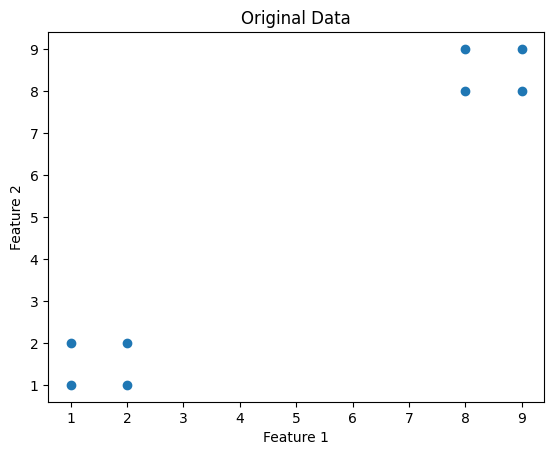

Cluster labels:
[0 0 0 0 1 1 1 1]


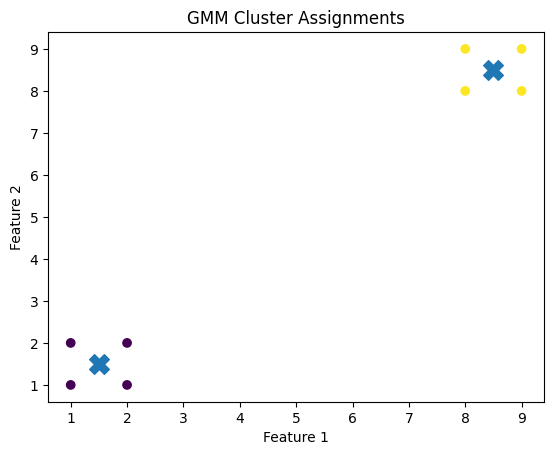

Responsibilities / probabilities:
[[1.00000000e+00 5.22439558e-98]
 [1.00000000e+00 7.55581902e-86]
 [1.00000000e+00 7.55581902e-86]
 [1.00000000e+00 1.09276566e-73]
 [1.09276566e-73 1.00000000e+00]
 [7.55581902e-86 1.00000000e+00]
 [7.55581902e-86 1.00000000e+00]
 [5.22439558e-98 1.00000000e+00]]


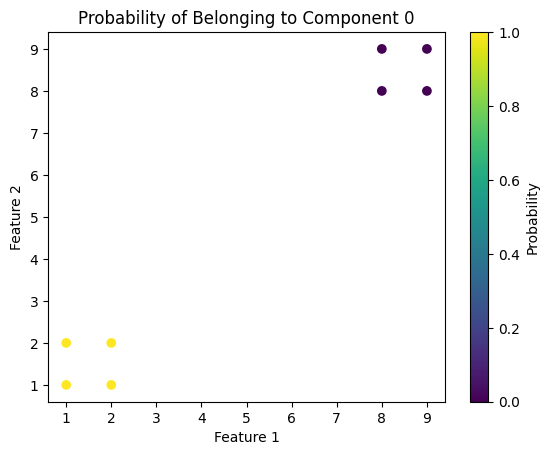

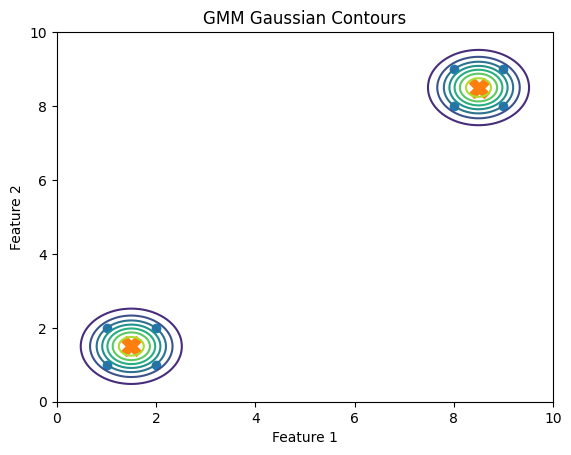

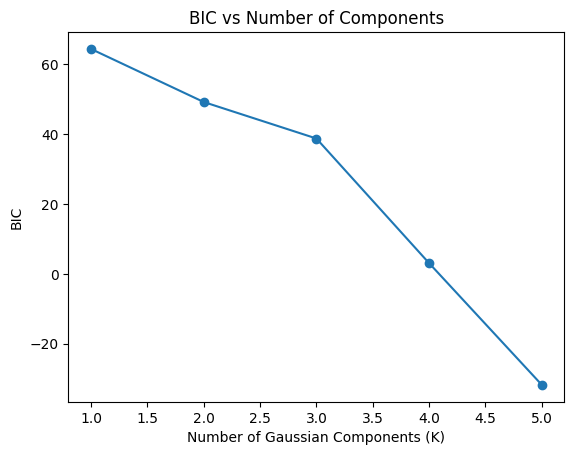

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from scipy.stats import multivariate_normal


# ============================================================
# 1. CREATE THE DATA
# ============================================================

X = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [2, 2],
    [8, 8],
    [8, 9],
    [9, 8],
    [9, 9]
])


# ============================================================
# 2. ORIGINAL DATA — SCATTER PLOT
# ============================================================

plt.scatter(X[:, 0], X[:, 1])

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Data")

plt.show()


# ============================================================
# 3. CREATE AND FIT GMM
# ============================================================

gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42
)

# Fit GMM using EM
gmm.fit(X)


# ============================================================
# 4. GET FINAL CLUSTER LABELS
# ============================================================

# Assign every point to the Gaussian
# with the highest probability
labels = gmm.predict(X)

print("Cluster labels:")
print(labels)


# ============================================================
# 5. CLUSTERED SCATTER PLOT
# ============================================================

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels
)

# Plot the learned Gaussian means
plt.scatter(
    gmm.means_[:, 0],
    gmm.means_[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("GMM Cluster Assignments")

plt.show()


# ============================================================
# 6. SOFT PROBABILITIES
# ============================================================

# Get probability of every point belonging
# to every Gaussian component
probs = gmm.predict_proba(X)

print("Responsibilities / probabilities:")
print(probs)


# ============================================================
# 7. PROBABILITY VISUALIZATION
# ============================================================

# Probability of each point belonging to
# Gaussian component 0
prob_component_0 = probs[:, 0]

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=prob_component_0
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Probability of Belonging to Component 0")

plt.colorbar(label="Probability")

plt.show()


# ============================================================
# 8. GAUSSIAN CONTOURS
# ============================================================

# Create a grid covering the data area
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Convert grid into coordinate pairs
grid = np.column_stack([
    xx.ravel(),
    yy.ravel()
])


# Draw one contour for each Gaussian
for k in range(gmm.n_components):

    # Calculate Gaussian probability density
    # at every grid point
    density = multivariate_normal.pdf(
        grid,
        mean=gmm.means_[k],
        cov=gmm.covariances_[k]
    )

    # Convert density back to grid shape
    density = density.reshape(xx.shape)

    # Draw contour
    plt.contour(
        xx,
        yy,
        density
    )


# Plot the actual data points
plt.scatter(
    X[:, 0],
    X[:, 1]
)

# Plot Gaussian means
plt.scatter(
    gmm.means_[:, 0],
    gmm.means_[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("GMM Gaussian Contours")

plt.show()


# ============================================================
# 9. BIC VS NUMBER OF COMPONENTS
# ============================================================

bic_values = []

# Try different numbers of Gaussian components
for k in range(1, 6):

    model = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42
    )

    # Fit GMM
    model.fit(X)

    # Calculate BIC
    bic_values.append(model.bic(X))


# Plot BIC values
plt.plot(
    range(1, 6),
    bic_values,
    marker="o"
)

plt.xlabel("Number of Gaussian Components (K)")
plt.ylabel("BIC")
plt.title("BIC vs Number of Components")

plt.show()

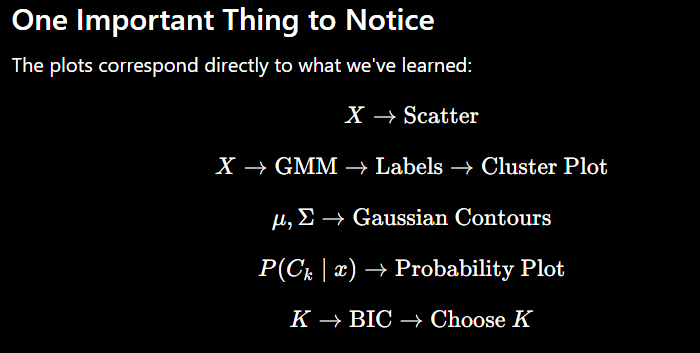